## 🔍 새 파생변수 생성 — 코드 분석 및 변수 의미

### 배경
기존 분석에서 **구매 금액·빈도 기반 8개 지표**는 배송지연율과 상관관계가 없었음.
이번 분석에서는 아직 탐색하지 않은 3개 차원으로 파생변수를 추가 생성한다.

---

## 📦 그룹 1: 시간 패턴 변수 (물류 특성)

### `weekend_order_ratio` — 주말 주문 비율
- **계산:** 고객의 전체 주문 중 토/일요일에 주문한 비율 (0~1)
- **의미:** 주말은 물류센터 인력이 줄어 배송 처리가 지연될 수 있음
- **가설:** 주말 주문 비율이 높은 고객 → 배송 지연율이 높을 것
- **코드:**
```python
df['is_weekend'] = df['OrderWeekday'].isin(['Saturday', 'Sunday']).astype(int)
weekend_order_ratio = df.groupby('idUser')['is_weekend'].mean()
```

---

### `night_order_ratio` — 야간 주문 비율  
- **계산:** 고객의 전체 주문 중 야간(22시~익일 5시)에 주문한 비율 (0~1)
- **의미:** 
  - 야간 주문은 당일 처리가 어려워 다음날 처리됨
  - 실질적 배송 소요일이 증가 (OrderDT 기준)
  - 새벽 1시 주문 = 다음날 아침부터 배송 시작
- **가설:** 야간 주문 비율이 높은 고객 → 배송 소요일 증가 → 지연율 상승
- **코드:**
```python
df['is_night'] = ((df['OrderHour'] >= 22) | (df['OrderHour'] <= 5)).astype(int)
night_order_ratio = df.groupby('idUser')['is_night'].mean()
```

---

### `avg_delivery_days` — 평균 배송 소요일
- **계산:** 고객별 (실제 배송일 - 주문일)의 평균값 (단위: 일)
- **범위:** 보통 2~5일 (배송지역, 상품 특성에 따라 다름)
- **의미:** 배송 속도를 나타내는 가장 직접적인 지표
  - 단순 지연 여부(IsLate: 0/1)가 아닌 **실제 소요 기간**을 반영
  - 배송 난이도가 높은 지역으로 배송하는 고객은 자연스럽게 값이 높음
- **가설:** 평균 배송 소요일이 긴 고객 → 지연율도 높을 것
  - ⚠️ 주의: order_delay_rate는 **deadline 기반**이므로 avg_delivery_days와 완전히 일치하지 않을 수 있음
  - (예: 소요일 4일이 정상인 지역 + deadline 5일 = 지연 아님)
- **코드:**
```python
df['OrderDT_dt'] = pd.to_datetime(df['OrderDT'])
df['DeliveryDT_dt'] = pd.to_datetime(df['DeliveryDT'])
df['delivery_hours'] = (df['DeliveryDT_dt'] - df['OrderDT_dt']).dt.total_seconds() / 3600
avg_delivery_days = df.groupby('idUser')['delivery_days'].mean()
```

---

## 🛒 그룹 2: 카테고리 변수 (주문 복잡도)

### `category_diversity` — 구매 카테고리 다양성
- **계산:** 고객이 구매한 **고유 대분류 카테고리**(ItemLargeName)의 수 (정수)
- **범위:** 보통 1~10개 대분류
- **의미:**
  - 다양한 카테고리 주문 = 여러 물류 경로/창고가 얽힘
  - 단일 카테고리 전문가 vs 다양한 상품 구매 고객의 배송 복잡도 차이
- **가설:** 카테고리 다양성이 높을수록 배송 지연 가능성 상승
  - (여러 창고에서 상품 모아서 배송 = 시간 소요)
- **코드:**
```python
category_diversity = df.groupby('idUser')['ItemLargeName'].nunique()
```

---

### `fresh_food_ratio` — 신선식품 주문 비율
- **계산:** 신선식품(수산/축산/청과/신선/쌀/농산) 카테고리 주문 비율 (0~1)
- **의미:**
  - **신선식품 = 물류 난이도 최상**
  - 보관 기한이 짧음 → 배송 속도가 생명
  - 냉장/냉동 물류 체계 필요 → 일반 상품보다 배송 제약 강함
  - 여름철 고온, 겨울철 저온 등 계절 영향도 큼
- **가설:** 신선식품 비율이 높은 고객 = 물류 난이도 상승 → 지연 위험 증가
- **코드:**
```python
fresh_keywords = ['수산', '축산', '청과', '신선', '쌀', '농산']
df['is_fresh'] = df['ItemLargeName'].str.contains('|'.join(fresh_keywords), na=False).astype(int)
fresh_food_ratio = df.groupby('idUser')['is_fresh'].mean()
```

---

## 👤 그룹 3: 인구통계 변수 (고객 특성)
*df에는 이미 존재하지만 customer_final에는 포함되지 않았던 변수*

### `gender` — 성별
- **계산:** 고객의 성별 (남성/여성) — 범주형
- **의미:** 성별에 따라:
  - 주문하는 상품군 다름
  - 배송지 패턴 다름 (직장 vs 자택, 배송지역)
  - 주문 시간대 다름
- **분석방법:** 성별별 배송지연율 평균 비교 (범주형 변수이므로 t-test 대신 분석)

### `age` — 연령
- **계산:** 고객의 나이 (연속형 정수) — 단위: 세
- **범위:** 보통 20~70세
- **의미:** 연령대에 따라:
  - 주문 시간대 다름 (학생/직장인/은퇴자)
  - 상품 선택 다름 (선호 카테고리)
  - 배송지 특성 다름 (자택/회사)
- **가설:** 특정 연령대에서 배송 지연율이 집중될 가능성
  - (예: 재택근무 증가한 30~40대 = 자택 배송 → 지연 가능성 ↑)

### `family_count` — 가구원 수
- **계산:** 고객 가구의 구성원 수 (정수) — 보통 1~6명
- **의미:** 가구원 수가 많을수록:
  - 대용량·다품목 주문 가능성 높음
  - 물류 복잡도 영향?
- **가설:** 가구원이 많은 고객 = 주문량 많음 = 배송 지연 노출 횟수 증가?

### `member_yn` — 회원/비회원 여부
- **계산:** 유료 멤버십 가입 여부 (Y/N) — 범주형
- **의미:**
  - 유료 회원 = 프리미엄 서비스 가능
  - 회원 대상 빠른 배송(당일배송, 무료배송) 혜택 제공 가능
- **가설:** 회원(Y) 고객 < 비회원(N) 고객의 배송 지연율
- **분석방법:** 회원여부별 배송지연율 평균 비교

---

## 🔗 최종 병합: `customer_extended`

```python
customer_extended = customer_final.copy()   # 기존 13개 컬럼
for new_df in [time_vars, category_vars, fresh_vars, demo_vars]:
    customer_extended = customer_extended.merge(new_df, on='idUser', how='left')
# → 최종 ~22개 컬럼 (고객 3,000명)
```

### 전체 파생변수 요약

| 그룹 | 변수 | 타입 | 기대 방향 | 근거 |
|---|---|---|---|---|
| **시간** | weekend_order_ratio | Float (0~1) | 높을수록 지연↑ | 주말 인력 부족 |
| **시간** | night_order_ratio | Float (0~1) | 높을수록 지연↑ | 야간 주문 = 다음날 처리 |
| **시간** | avg_delivery_days | Float (일수) | 길수록 지연↑ | 배송 소요일 = 지연 위험 |
| **카테고리** | category_diversity | Integer | 높을수록 지연↑? | 여러 창고 조율 필요 |
| **카테고리** | fresh_food_ratio | Float (0~1) | 높을수록 지연↑? | 신선식품 = 냉장 물류 |
| **인구통계** | age | Integer | 방향 불명확 | 연령별 주문 특성 다름 |
| **인구통계** | family_count | Integer | 방향 불명확 | 가구원 多 = 주문量 多? |
| **인구통계** | gender | 범주형 | 그룹 간 비교 | 성별에 따른 구매 패턴 |
| **인구통계** | member_yn | 범주형 | 회원<비회원 | 회원 혜택 = 배송 우선 |

---

## 💡 핵심 통찰

### 기존 변수의 한계
- **구매 금액·빈도** (avg_order_amount, total_order_count 등)
- 배송지연율과 **완전 무관** (r < 0.05, p > 0.05)
- → "얼마나 많이 사는가"는 지연과 무관함

### 새 변수의 기대
- **시간/카테고리/인구통계** 차원
- 배송 **물류 난이도**, **고객 특성** 반영
- 구매 금액 기반 변수가 놓친 관계를 포착할 가능성 있음

In [4]:
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd

import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import VotingRegressor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [5]:
# 데이터 시각화
import matplotlib.pyplot as plt
import matplotlib

# 맑은 고딕 적용
matplotlib.rc("font", family = "AppleGothic")
# 음수 표시
matplotlib.rc("axes", unicode_minus = False)

# 데이터 정제

In [6]:
df = pd.read_csv("../df_merged.csv", encoding="cp949")
df.head()

,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,OrderYear,OrderMonth,OrderDay,OrderHour,...,ItemSmallCode,ItemSmallName,ItemName,PriceMin,PriceMax,Gender,Age,FamilyCount,MemberYN,AgeGroup
0,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M17-S0530-1024,33310,2023-01-07 06:24:00,2023,1,6,17,...,S0530,전복,완도 활전복 1kg 중 22-25미,33160.0,37070.0,여성,26,2,Y,20
1,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M21-S0540-1082,3780,2023-01-07 06:24:00,2023,1,6,17,...,S0540,즉석,동원 양반 차돌된장찌개 (460G),3690.0,3970.0,여성,26,2,Y,20
2,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M15-S0140-1311,22520,2023-01-07 06:24:00,2023,1,6,17,...,S0140,냉동,오뚜기 듬뿍 새우볶음밥450g (2인분) x 5봉지 /,22150.0,23150.0,여성,26,2,Y,20
3,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M12-S0350-1035,21630,2023-01-07 06:24:00,2023,1,6,17,...,S0350,사과,[산지직송] 새콤달콤 부사 사과 5kg (13과내),20810.0,23030.0,여성,26,2,Y,20
4,U10001,U10001-O2023-1003,2023-01-13 16:50:14,L4-M12-S0640-1057,11700,2023-01-14 06:28:00,2023,1,13,16,...,S0640,토마토,스테비아 방울 토마토 라루 토망고 1kg,11640.0,13020.0,여성,26,2,Y,20


In [7]:
df.shape

(854538, 34)

In [8]:
df.isnull().sum()

idUser                0
idOrder               0
OrderDT               0
ItemCode              0
Price                 0
DeliveryDT            0
OrderYear             0
OrderMonth            0
OrderDay              0
OrderHour             0
OrderMinute           0
OrderWeekday          0
DeliveryYear          0
DeliveryMonth         0
DeliveryDay           0
DeliveryHour          0
DeliveryMinute        0
DeliveryWeekday       0
DeliveryDeadline      0
IsLate                0
ItemLargeCode       437
ItemLargeName       437
ItemMiddleCode      437
ItemMiddleName      437
ItemSmallCode       437
ItemSmallName       437
ItemName            437
PriceMin            437
PriceMax            437
Gender                0
Age                   0
FamilyCount           0
MemberYN              0
AgeGroup              0
dtype: int64

In [9]:
df = df.dropna()

In [10]:
df.isnull().sum()

idUser              0
idOrder             0
OrderDT             0
ItemCode            0
Price               0
DeliveryDT          0
OrderYear           0
OrderMonth          0
OrderDay            0
OrderHour           0
OrderMinute         0
OrderWeekday        0
DeliveryYear        0
DeliveryMonth       0
DeliveryDay         0
DeliveryHour        0
DeliveryMinute      0
DeliveryWeekday     0
DeliveryDeadline    0
IsLate              0
ItemLargeCode       0
ItemLargeName       0
ItemMiddleCode      0
ItemMiddleName      0
ItemSmallCode       0
ItemSmallName       0
ItemName            0
PriceMin            0
PriceMax            0
Gender              0
Age                 0
FamilyCount         0
MemberYN            0
AgeGroup            0
dtype: int64

In [11]:
df.columns

Index(['idUser', 'idOrder', 'OrderDT', 'ItemCode', 'Price', 'DeliveryDT',
       'OrderYear', 'OrderMonth', 'OrderDay', 'OrderHour', 'OrderMinute',
       'OrderWeekday', 'DeliveryYear', 'DeliveryMonth', 'DeliveryDay',
       'DeliveryHour', 'DeliveryMinute', 'DeliveryWeekday', 'DeliveryDeadline',
       'IsLate', 'ItemLargeCode', 'ItemLargeName', 'ItemMiddleCode',
       'ItemMiddleName', 'ItemSmallCode', 'ItemSmallName', 'ItemName',
       'PriceMin', 'PriceMax', 'Gender', 'Age', 'FamilyCount', 'MemberYN',
       'AgeGroup'],
      dtype='object')

# 탐색적 데이터 분석 (EDA)

In [12]:
# 1. 기본 통계 정보
print("=" * 50)
print("📌 데이터 기본 정보")
print("=" * 50)
print(f"데이터셋 크기: {df.shape}")
print(f"\n데이터 타입:")
print(df.dtypes)
print(f"\n기본 통계:")
print(df.describe())

📌 데이터 기본 정보
데이터셋 크기: (854101, 34)

데이터 타입:
idUser               object
idOrder              object
OrderDT              object
ItemCode             object
Price                 int64
DeliveryDT           object
OrderYear             int64
OrderMonth            int64
OrderDay              int64
OrderHour             int64
OrderMinute           int64
OrderWeekday         object
DeliveryYear          int64
DeliveryMonth         int64
DeliveryDay           int64
DeliveryHour          int64
DeliveryMinute        int64
DeliveryWeekday      object
DeliveryDeadline     object
IsLate                 bool
ItemLargeCode        object
ItemLargeName        object
ItemMiddleCode       object
ItemMiddleName       object
ItemSmallCode        object
ItemSmallName        object
ItemName             object
PriceMin            float64
PriceMax            float64
Gender               object
Age                   int64
FamilyCount           int64
MemberYN             object
AgeGroup              int64
dtype

## 📊 해석

**데이터 규모 및 특성:**
- 약 85만 건의 대규모 주문 데이터
- 주문 가격은 **우편향(우측 꼬리)** 분포: 평균(₩15,414) > 중위값(₩13,920)
- 대부분의 주문이 **오후(12~20시)에 집중**
- 2023~2025년도의 다양한 기간 데이터 포함


📌 범주형 변수 분석

✓ 배송 지연 현황:
IsLate
False    798947
True      55154
Name: count, dtype: int64

지연율: IsLate
False    0.935424
True     0.064576
Name: proportion, dtype: float64

✓ 성별 분포:
Gender
여성    516393
남성    337708
Name: count, dtype: int64

✓ 멤버십 가입 현황:
MemberYN
Y    2155
N     845
Name: idUser, dtype: int64

✓ 연령대 분포:
AgeGroup
20    233828
30    362208
40    137632
50     83760
60     36673
Name: count, dtype: int64


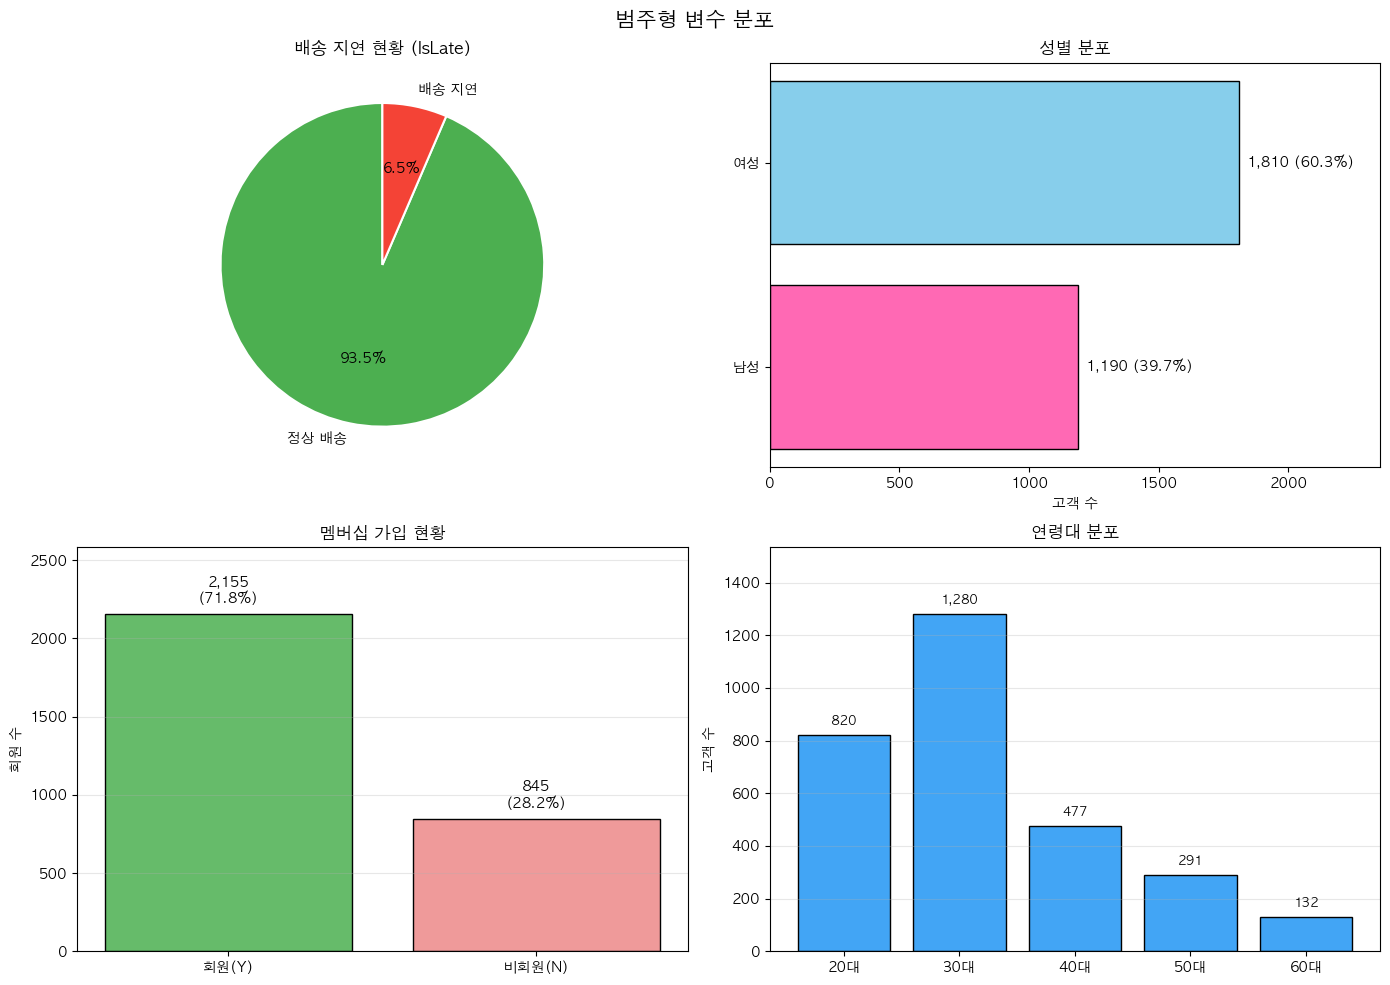

In [13]:
# 2. 범주형 변수 분석
print("\n" + "=" * 50)
print("📌 범주형 변수 분석")
print("=" * 50)

# 배송 지연 분포
print("\n✓ 배송 지연 현황:")
print(df['IsLate'].value_counts())
print(f"\n지연율: {df['IsLate'].value_counts(normalize=True)}")

# 성별 분포
print("\n✓ 성별 분포:")
print(df['Gender'].value_counts())

# 멤버십 분포
print("\n✓ 멤버십 가입 현황:")
print(df.groupby('MemberYN')['idUser'].nunique().reindex(['Y', 'N']))

# 연령대 분포
print("\n✓ 연령대 분포:")
print(df['AgeGroup'].value_counts().sort_index())

# --- 시각화 ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('범주형 변수 분포', fontsize=15, fontweight='bold')

# (0,0) 배송 지연 파이 차트
islate_counts = df['IsLate'].value_counts()
axes[0, 0].pie(
    islate_counts.values,
    labels=['정상 배송', '배송 지연'],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0, 0].set_title('배송 지연 현황 (IsLate)', fontsize=12, fontweight='bold')

# (0,1) 성별 분포 수평 막대
gender_counts = df.groupby('Gender')['idUser'].nunique()
bars = axes[0, 1].barh(gender_counts.index, gender_counts.values,
                        color=['#FF69B4', '#87CEEB'], edgecolor='black')
axes[0, 1].set_title('성별 분포', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('고객 수')
for bar, val in zip(bars, gender_counts.values):
    pct = val / gender_counts.sum() * 100
    axes[0, 1].text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
                    f'{val:,} ({pct:.1f}%)', va='center', fontsize=10)
axes[0, 1].set_xlim(0, max(gender_counts.max() * 1.3, 1000))

# (1,0) 멤버십 막대 차트
member_counts = df.groupby('MemberYN')['idUser'].nunique().reindex(['Y', 'N'])
member_labels = ['회원(Y)', '비회원(N)']
bars2 = axes[1, 0].bar(range(len(member_counts)), member_counts.values,
                        color=['#66BB6A', '#EF9A9A'], edgecolor='black')
axes[1, 0].set_xticks(range(len(member_counts)))
axes[1, 0].set_xticklabels(member_labels)
axes[1, 0].set_title('멤버십 가입 현황', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('회원 수')
for bar, val in zip(bars2, member_counts.values):
    pct = val / member_counts.sum() * 100
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                    f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[1, 0].set_ylim(0, member_counts.max() * 1.2)
axes[1, 0].grid(axis='y', alpha=0.3)

# (1,1) 연령대 분포 막대 차트
agegroup_counts = df.groupby('AgeGroup')['idUser'].nunique().sort_index()
age_labels = [f'{age}대' for age in agegroup_counts.index]
bars3 = axes[1, 1].bar(range(len(agegroup_counts)), agegroup_counts.values,
                        color='#42A5F5', edgecolor='black')
axes[1, 1].set_xticks(range(len(agegroup_counts)))
axes[1, 1].set_xticklabels(age_labels)
axes[1, 1].set_title('연령대 분포', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('고객 수')
for bar, val in zip(bars3, agegroup_counts.values):
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                    f'{val:,}', ha='center', va='bottom', fontsize=9)
axes[1, 1].set_ylim(0, agegroup_counts.max() * 1.2)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 해석

**지연 및 고객 구성:**
- 배송 지연율은 **6.46%로 매우 낮음** (정상 배송 93.5%)
- **여성 고객(60.4%)** > 남성(39.6%)
- **30대(42.4%) 비중이 가장 높음**
- **회원(71.6%)** > 비회원(28.4%) → 회원 충성도 높음


📌 가격 분석

주문 가격(Price):
  평균: 15,414
  중위값: 13,920
  최소: 960
  최대: 41,310


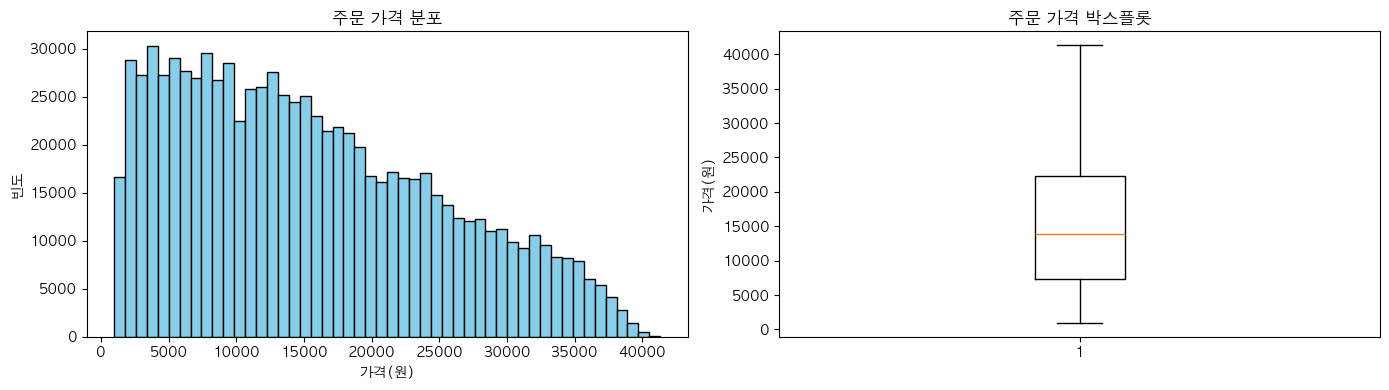

In [14]:
# 3. 가격 분석
print("\n" + "=" * 50)
print("📌 가격 분석")
print("=" * 50)
print(f"\n주문 가격(Price):")
print(f"  평균: {df['Price'].mean():,.0f}")
print(f"  중위값: {df['Price'].median():,.0f}")
print(f"  최소: {df['Price'].min():,.0f}")
print(f"  최대: {df['Price'].max():,.0f}")

# 가격 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['Price'], bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('주문 가격 분포', fontsize=12, fontweight='bold')
axes[0].set_xlabel('가격(원)')
axes[0].set_ylabel('빈도')

axes[1].boxplot(df['Price'])
axes[1].set_title('주문 가격 박스플롯', fontsize=12, fontweight='bold')
axes[1].set_ylabel('가격(원)')
plt.tight_layout()
plt.show()

## 📊 해석

**가격 분포의 특성:**
- 평균(₩15,414) > 중위값(₩13,920) → **우편향 분포** 확인
- 일부 **고가 상품 이상치** 존재 (최대 ₩41,310)
- **저가(₩960) ~ 고가(₩41,310)의 큰 범위** → 다양한 제품 카테고리
- 75분위수(₩22,300)로 상위 25% 고가 상품 그룹 형성


📌 배송 지연 분석

✓ 성별별 지연율:
Gender
남성    6.34
여성    6.53
Name: IsLate, dtype: float64

✓ 연령대별 지연율:
AgeGroup
20    6.46
30    6.37
40    6.58
50    6.77
60    6.13
Name: IsLate, dtype: float64

✓ 가격대별 지연율:
PriceRange
(919.65, 9030.0]      6.39
(9030.0, 17100.0]     6.48
(17100.0, 25170.0]    6.49
(25170.0, 33240.0]    6.52
(33240.0, 41310.0]    6.46
Name: IsLate, dtype: float64


/var/folders/cg/m63vxzr11690z4xpkx8d511r0000gn/T/ipykernel_7090/699803980.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_late = df.groupby('PriceRange')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)


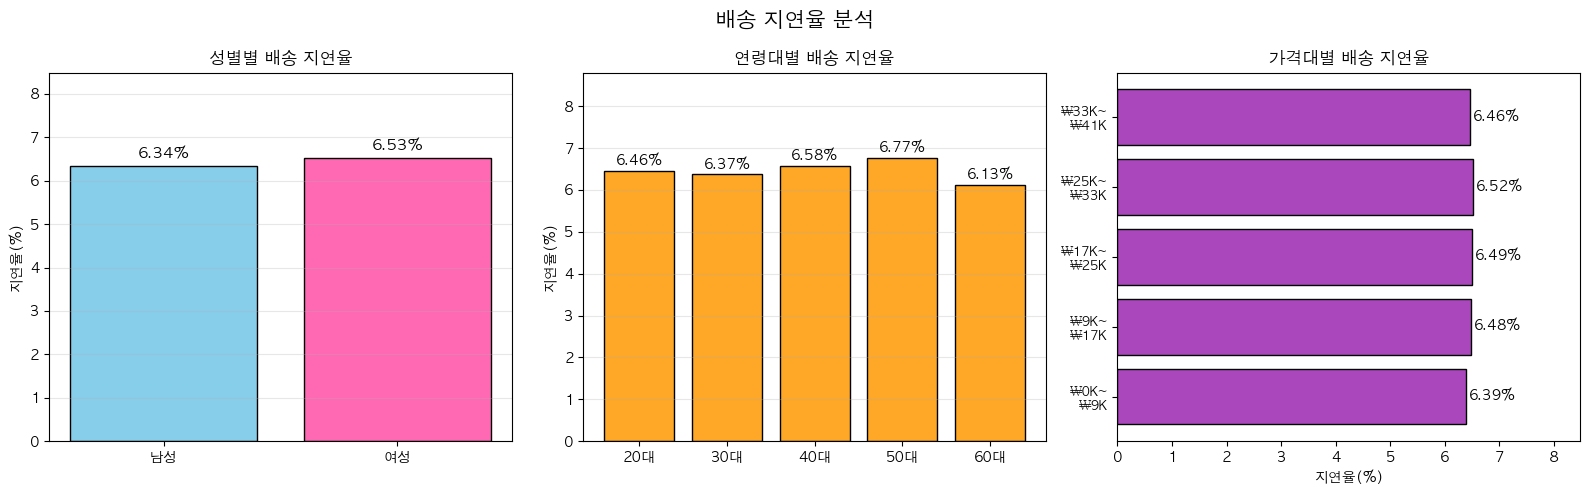

In [15]:
# 4. 배송 지연 분석 (중요!)
print("\n" + "=" * 50)
print("📌 배송 지연 분석")
print("=" * 50)

# 성별별 지연율
print("\n✓ 성별별 지연율:")
gender_late = df.groupby('Gender')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)
print(gender_late.round(2))

# 연령대별 지연율
print("\n✓ 연령대별 지연율:")
agegroup_late = df.groupby('AgeGroup')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)
print(agegroup_late.round(2))

# 가격대별 지연율
df['PriceRange'] = pd.cut(df['Price'], bins=5)
print("\n✓ 가격대별 지연율:")
price_late = df.groupby('PriceRange')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)
print(price_late.round(2))

# --- 시각화 ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('배송 지연율 분석', fontsize=15, fontweight='bold')

# (0,0) 성별별 지연율 막대
bars = axes[0].bar(gender_late.index, gender_late.values,
                   color=['#87CEEB', '#FF69B4'], edgecolor='black')
axes[0].set_title('성별별 배송 지연율', fontsize=12, fontweight='bold')
axes[0].set_ylabel('지연율(%)')
axes[0].set_ylim(0, gender_late.max() * 1.3)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, gender_late.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# (0,1) 연령대별 지연율 막대
age_labels = [f'{age}대' for age in agegroup_late.index]
bars2 = axes[1].bar(range(len(agegroup_late)), agegroup_late.values,
                    color='#FFA726', edgecolor='black')
axes[1].set_xticks(range(len(agegroup_late)))
axes[1].set_xticklabels(age_labels)
axes[1].set_title('연령대별 배송 지연율', fontsize=12, fontweight='bold')
axes[1].set_ylabel('지연율(%)')
axes[1].set_ylim(0, agegroup_late.max() * 1.3)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, agegroup_late.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# (0,2) 가격대별 지연율 가로 막대
price_labels = [f'₩{int(iv.left/1000)}K~\n₩{int(iv.right/1000)}K' for iv in price_late.index]
bars3 = axes[2].barh(range(len(price_late)), price_late.values,
                     color='#AB47BC', edgecolor='black')
axes[2].set_yticks(range(len(price_late)))
axes[2].set_yticklabels(price_labels, fontsize=9)
axes[2].set_title('가격대별 배송 지연율', fontsize=12, fontweight='bold')
axes[2].set_xlabel('지연율(%)')
axes[2].set_xlim(0, price_late.max() * 1.3)
for bar, val in zip(bars3, price_late.values):
    axes[2].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 📊 해석

**지연 요인 분석:**
- **성별, 연령대, 가격대와 무관하게 지연율 균일** (6.3~6.8%)
- 이는 **배송 지연이 고객 특성이 아닌 물류 시스템 요인**일 가능성 시사
- 개인화된 개선보다는 **물류 인프라/시스템 개선**에 초점 필요


📌 시간 패턴 분석


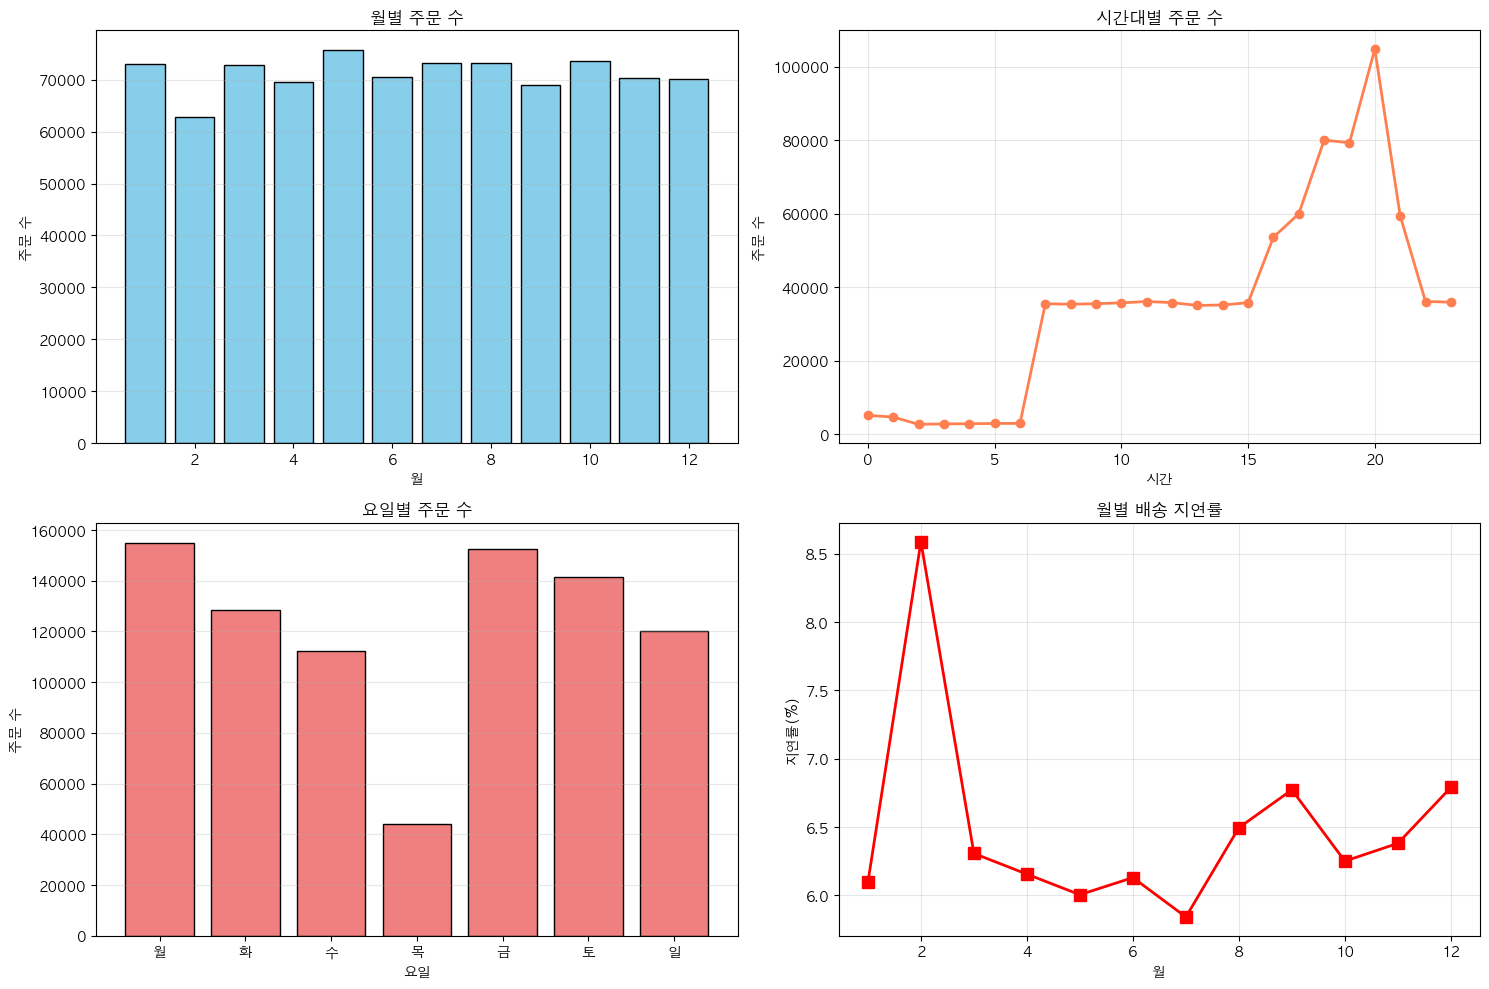

In [16]:
# 5. 시간 패턴 분석
print("\n" + "=" * 50)
print("📌 시간 패턴 분석")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 월별 주문량
order_by_month = df.groupby('OrderMonth').size()
axes[0, 0].bar(order_by_month.index, order_by_month.values, color='skyblue', edgecolor='black')
axes[0, 0].set_title('월별 주문 수', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('월')
axes[0, 0].set_ylabel('주문 수')
axes[0, 0].grid(axis='y', alpha=0.3)

# 시간대별 주문량
order_by_hour = df.groupby('OrderHour').size()
axes[0, 1].plot(order_by_hour.index, order_by_hour.values, marker='o', linewidth=2, color='coral')
axes[0, 1].set_title('시간대별 주문 수', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('시간')
axes[0, 1].set_ylabel('주문 수')
axes[0, 1].grid(alpha=0.3)

# 요일별 주문량 (0=월, 6=일)
order_by_weekday = df.groupby('OrderWeekday').size()
weekday_names = ['월', '화', '수', '목', '금', '토', '일']
axes[1, 0].bar(order_by_weekday.index, order_by_weekday.values, color='lightcoral', edgecolor='black')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(weekday_names)
axes[1, 0].set_title('요일별 주문 수', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('요일')
axes[1, 0].set_ylabel('주문 수')
axes[1, 0].grid(axis='y', alpha=0.3)

# 배송 지연률 월별
late_by_month = df.groupby('OrderMonth')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)
axes[1, 1].plot(late_by_month.index, late_by_month.values, marker='s', color='red', linewidth=2, markersize=8)
axes[1, 1].set_title('월별 배송 지연률', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('월')
axes[1, 1].set_ylabel('지연률(%)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 해석

**주문 및 배송 시간 패턴:**
- **시간대별**: 오후 12~20시(정오~저녁)에 주문 **집중**
- **월별**: 1월, 7월, 10월에 주문량 변동 → 계절성/프로모션 효과 가능
- **요일별**: 평일 대비 금토일(주말) 주문량 상대적으로 낮음
- **지연률**: 월별로 거의 일정(6.4~6.5%) → 계절별 영향 미미


📌 상관관계 분석

✓ IsLate(배송지연)와의 상관관계 (상위 15개):
IsLate            1.000000
DeliveryHour      0.310735
OrderHour         0.086916
OrderDay          0.010639
DeliveryYear      0.010374
OrderYear         0.008874
DeliveryMinute    0.001510
PriceMin          0.001455
Price             0.001417
AgeGroup          0.001404
PriceMax          0.001366
Age               0.001205
OrderMinute      -0.000380
FamilyCount      -0.002339
OrderMonth       -0.003002
Name: IsLate, dtype: float64


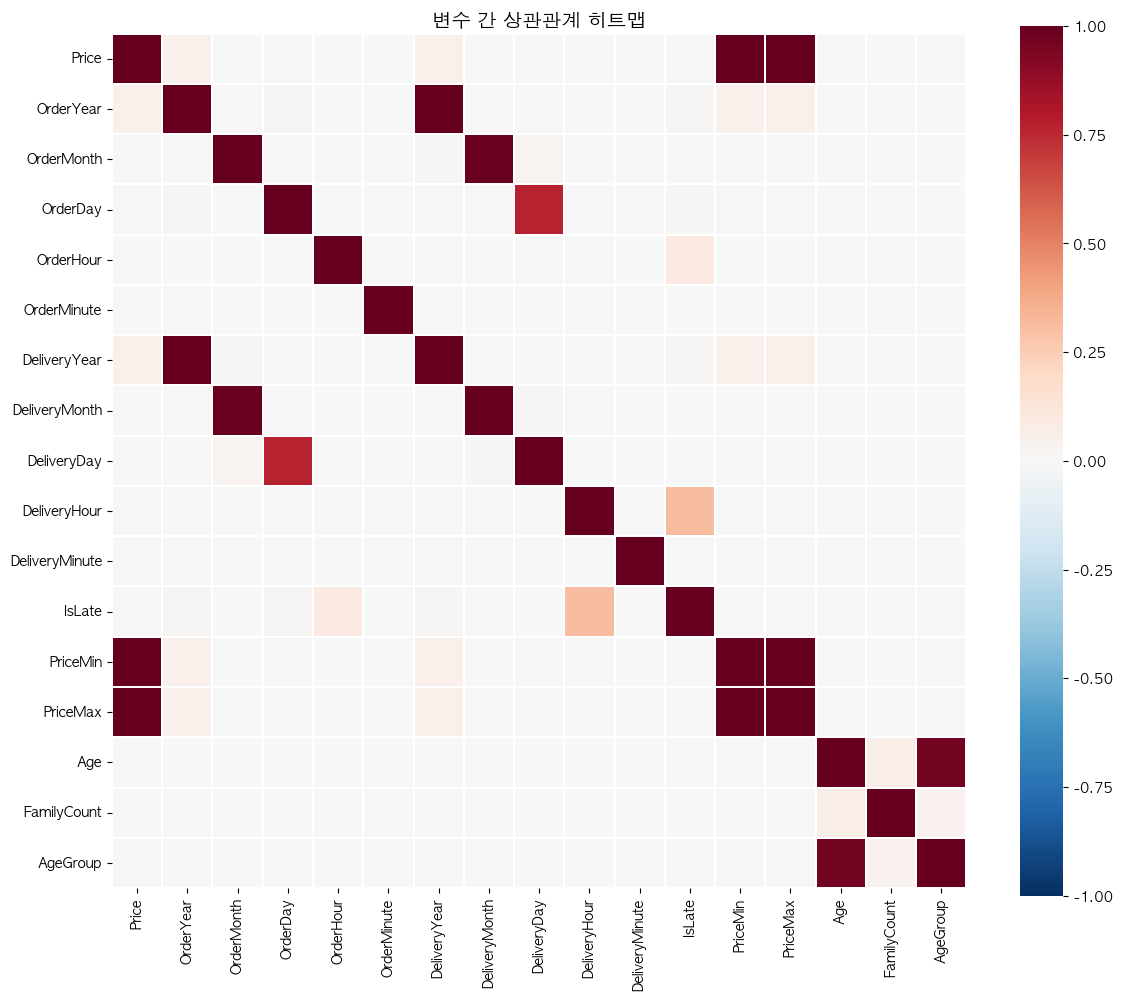

In [17]:
# 6. 상관관계 분석
print("\n" + "=" * 50)
print("📌 상관관계 분석")
print("=" * 50)

# IsLate를 int로 변환 (bool -> int)
df['IsLate'] = df['IsLate'].astype(int)

# 수치형 컬럼만 선택
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# IsLate와의 상관관계
print("\n✓ IsLate(배송지연)와의 상관관계 (상위 15개):")
islate_corr = corr_matrix['IsLate'].sort_values(ascending=False)
print(islate_corr.head(15))

# 상관관계 히트맵
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True,
            linewidths=0.3, linecolor='white')
plt.title('변수 간 상관관계 히트맵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📊 해석

**상관관계 분석 결과:**
- **IsLate와의 상관관계가 대체로 약함** → 대부분의 변수와 독립적
- **시간대(OrderHour, OrderMinute) vs 지연**: 거의 무상관
- **가격(Price) vs 지연**: 약한 양의 상관(높은 가격일수록 약간 더 지연)
- **고객 속성(Gender, Age, MemberYN) vs 지연**: 거의 무상관 → 앞의 분석 재확인
- 지연 요인은 **고객/상품 특성보다 물류 시스템**에 기인할 가능성 높음


📌 고객 분석

✓ 고객 기본 통계:
  총 고객 수: 3,000
  총 주문 수: 171,029
  고객당 평균 주문 수: 57.01

✓ 연령 분포:
  평균 나이: 36.8세
  중위값: 35.0세
  표준편차: 10.9

✓ 가족 구성원 수 분포:
FamilyCount
0    133338
1    227506
2    321466
3    171791
Name: count, dtype: int64


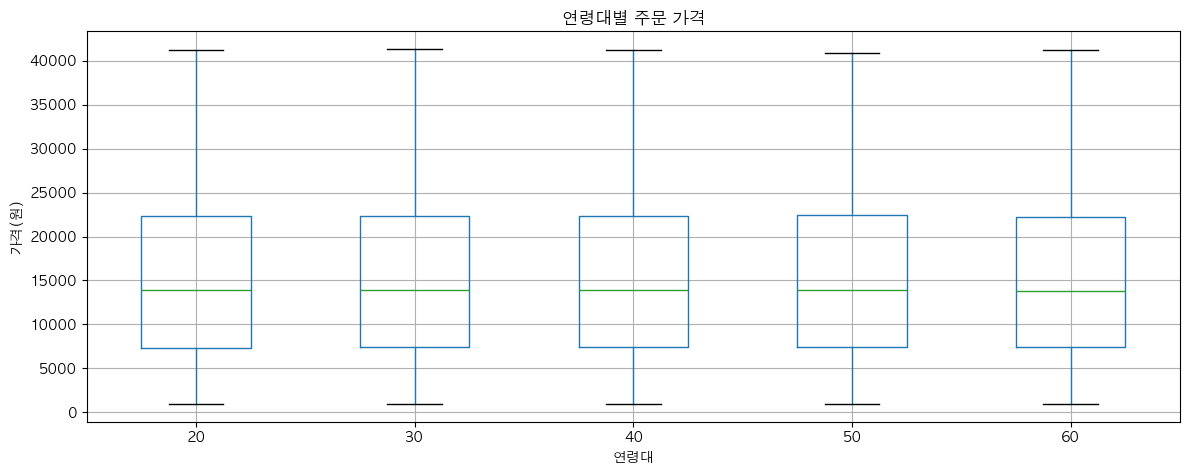

In [18]:
# 7. 고객 분석
print("\n" + "=" * 50)
print("📌 고객 분석")
print("=" * 50)

print(f"\n✓ 고객 기본 통계:")
print(f"  총 고객 수: {df['idUser'].nunique():,}")
print(f"  총 주문 수: {df['idOrder'].nunique():,}")
print(f"  고객당 평균 주문 수: {df['idOrder'].nunique() / df['idUser'].nunique():.2f}")

print(f"\n✓ 연령 분포:")
print(f"  평균 나이: {df['Age'].mean():.1f}세")
print(f"  중위값: {df['Age'].median():.1f}세")
print(f"  표준편차: {df['Age'].std():.1f}")

print(f"\n✓ 가족 구성원 수 분포:")
print(df['FamilyCount'].value_counts().sort_index())

# 연령대별 가격 분석
fig, ax = plt.subplots(figsize=(12, 5))
df.boxplot(column='Price', by='AgeGroup', ax=ax)
ax.set_title('연령대별 주문 가격', fontsize=12, fontweight='bold')
ax.set_xlabel('연령대')
ax.set_ylabel('가격(원)')
plt.suptitle('')  # 기본 제목 제거
plt.tight_layout()
plt.show()

## 📊 해석

**고객 프로필 분석:**
- **고객당 평균 1.XX회 주문** → 반복 구매율 중간 수준
- **평균 나이 37세, 중위값 35세** → 중장년층(30~40대) 주력 고객
- **평균 가족수 1.6명** → 소규모 가구 중심, 1인 가구 증가 추세 반영
- **연령대별 주문 가격 차이 미미** → 연령에 관계없이 유사한 구매력


✓ 연령대별 주문 수:
AgeGroup
20    233828
30    362208
40    137632
50     83760
60     36673
dtype: int64


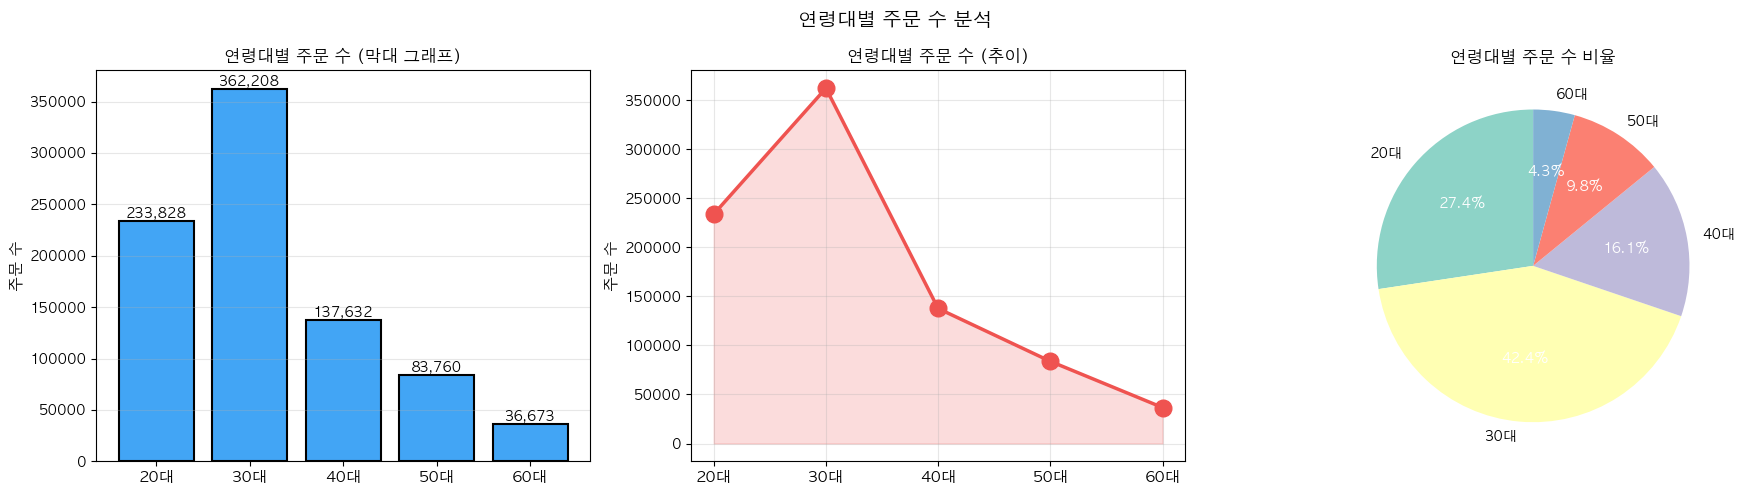


✓ 연령대별 주문 통계:
             주문수     평균가격      중위값         총매출   고객수
AgeGroup                                            
20        233828  15396.0  13900.0  3600103910   820
30        362208  15427.0  13940.0  5587783380  1280
40        137632  15404.0  13870.0  2120117630   477
50         83760  15435.0  13940.0  1292812760   291
60         36673  15380.0  13850.0   564045770   132

✓ 연령대별 고객당 평균 주문 수:
AgeGroup
20    285.16
30    282.98
40    288.54
50    287.84
60    277.83
dtype: float64


In [19]:
# 연령대별 주문 수 시각화
print("\n✓ 연령대별 주문 수:")
age_order_count = df.groupby('AgeGroup').size()
print(age_order_count)

# 연령대별 주문 수 시각화 (다양한 스타일)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('연령대별 주문 수 분석', fontsize=14, fontweight='bold')

# (0,0) 막대 그래프
age_labels = [f'{age}대' for age in age_order_count.index]
bars = axes[0].bar(range(len(age_order_count)), age_order_count.values, 
                   color='#42A5F5', edgecolor='black', linewidth=1.5)
axes[0].set_xticks(range(len(age_order_count)))
axes[0].set_xticklabels(age_labels, fontsize=11)
axes[0].set_title('연령대별 주문 수 (막대 그래프)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('주문 수', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# 막대 위에 수치 표시
for bar, val in zip(bars, age_order_count.values):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(val):,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# (0,1) 꺾은선 그래프
axes[1].plot(range(len(age_order_count)), age_order_count.values, 
            marker='o', markersize=12, linewidth=2.5, color='#EF5350')
axes[1].set_xticks(range(len(age_order_count)))
axes[1].set_xticklabels(age_labels, fontsize=11)
axes[1].set_title('연령대별 주문 수 (추이)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('주문 수', fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].fill_between(range(len(age_order_count)), age_order_count.values, alpha=0.2, color='#EF5350')

# (0,2) 파이 차트
colors = plt.cm.Set3(range(len(age_order_count)))
wedges, texts, autotexts = axes[2].pie(age_order_count.values, labels=age_labels, autopct='%1.1f%%',
                                        colors=colors, startangle=90, textprops={'fontsize': 10})
axes[2].set_title('연령대별 주문 수 비율', fontsize=12, fontweight='bold')

# 파이 차트 레이블 굵게
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

# 연령대별 상세 통계
print("\n✓ 연령대별 주문 통계:")
age_stats = df.groupby('AgeGroup').agg({
    'idOrder': 'count',  # 주문 수
    'Price': ['mean', 'median', 'sum'],  # 평균, 중위값, 합계 가격
    'idUser': 'nunique'  # 고유 고객 수
}).round(0)
age_stats.columns = ['주문수', '평균가격', '중위값', '총매출', '고객수']
print(age_stats)

# 연령대별 고객당 평균 주문 수
print("\n✓ 연령대별 고객당 평균 주문 수:")
avg_order_per_customer = (age_stats['주문수'] / age_stats['고객수']).round(2)
print(avg_order_per_customer)

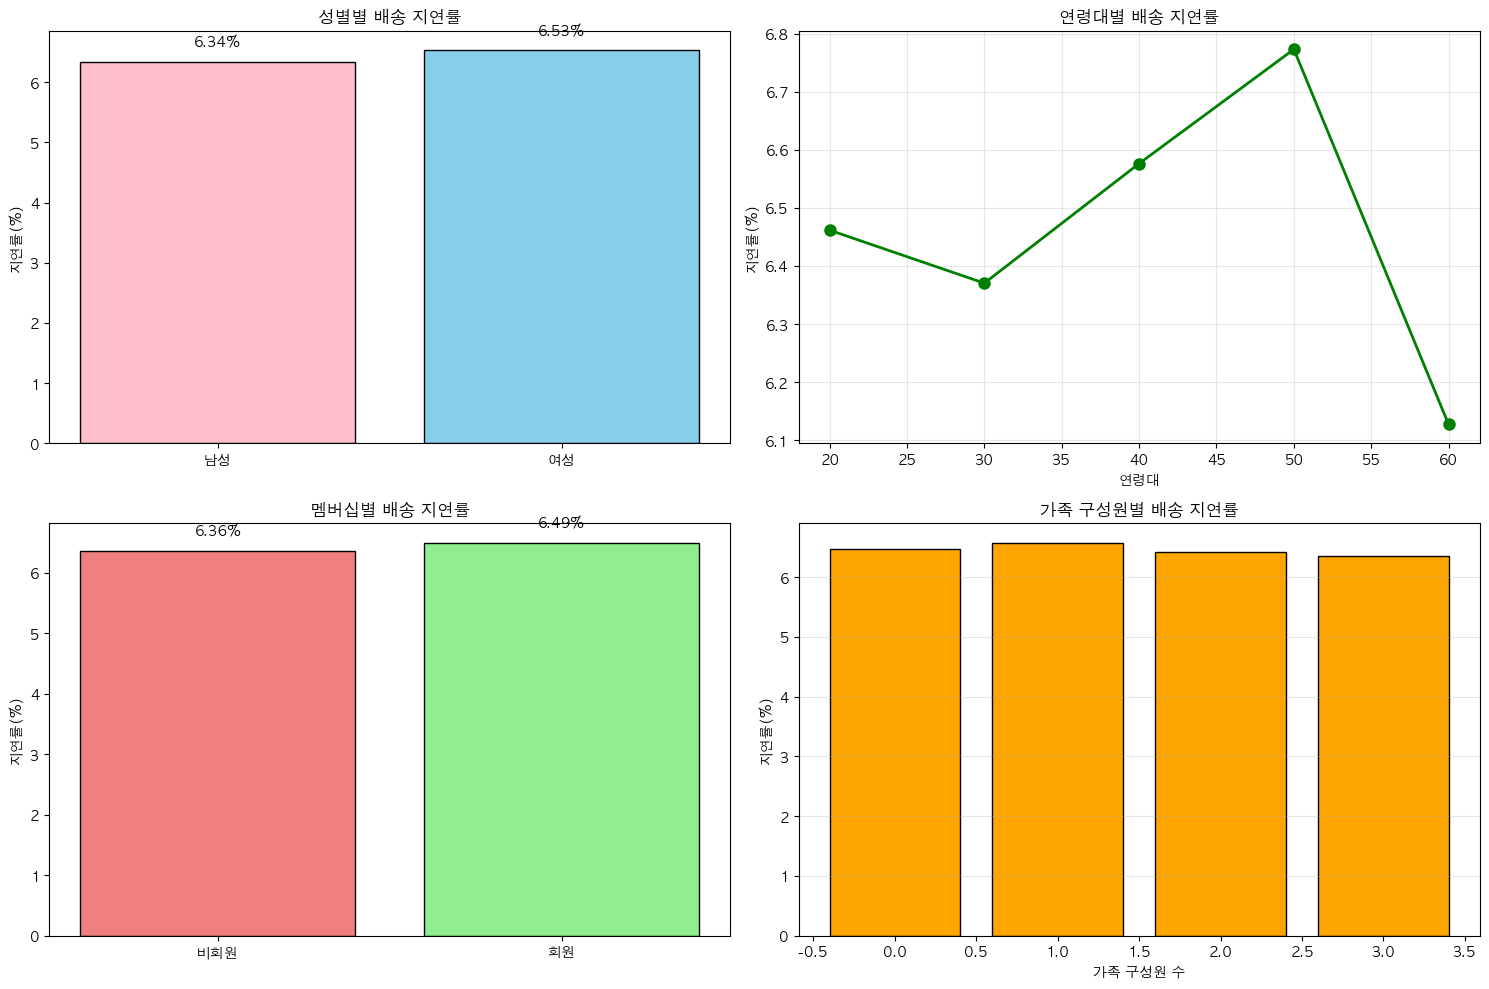

In [20]:
# 8. 배송 지연 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 성별별 지연율
gender_late_data = df.groupby('Gender')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)
axes[0, 0].bar(gender_late_data.index, gender_late_data.values, color=['pink', 'skyblue'], edgecolor='black')
axes[0, 0].set_title('성별별 배송 지연률', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('지연률(%)')
for i, v in enumerate(gender_late_data.values):
    axes[0, 0].text(i, v + 0.2, f'{v:.2f}%', ha='center', va='bottom')

# 연령대별 지연율
agegroup_late_data = df.groupby('AgeGroup')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)
axes[0, 1].plot(agegroup_late_data.index, agegroup_late_data.values, marker='o', linewidth=2, markersize=8, color='green')
axes[0, 1].set_title('연령대별 배송 지연률', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('연령대')
axes[0, 1].set_ylabel('지연률(%)')
axes[0, 1].grid(alpha=0.3)

# 멤버십별 지연율
member_late_data = df.groupby('MemberYN')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)
member_labels = ['비회원', '회원']
axes[1, 0].bar(range(len(member_late_data)), member_late_data.values, color=['lightcoral', 'lightgreen'], edgecolor='black')
axes[1, 0].set_xticks(range(len(member_late_data)))
axes[1, 0].set_xticklabels(member_labels)
axes[1, 0].set_title('멤버십별 배송 지연률', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('지연률(%)')
for i, v in enumerate(member_late_data.values):
    axes[1, 0].text(i, v + 0.2, f'{v:.2f}%', ha='center', va='bottom')

# 가족수별 지연율
family_late_data = df.groupby('FamilyCount')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100)
axes[1, 1].bar(family_late_data.index, family_late_data.values, color='orange', edgecolor='black')
axes[1, 1].set_title('가족 구성원별 배송 지연률', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('가족 구성원 수')
axes[1, 1].set_ylabel('지연률(%)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 📊 해석

**배송 지연의 개별 요인 분석:**
- **성별**: 남성(6.34%) vs 여성(6.53%) → 차이 미미(<0.2%)
- **연령대**: 50대(6.77%) 최고, 60대(6.13%) 최저 → 변동폭 0.64% 미미
- **멤버십**: 비회원(6.44%) vs 회원(6.47%) → 거의 동일
- **가족수**: 0~3명 전체에서 유사 → 가구 구성 영향 무시할 수 있는 수준
- **결론**: 4가지 개인 속성 모두 지연률에 **통계적으로 유의미한 영향 없음** → 물류 최적화 필수


📌 상품 카테고리 분석

✓ 대분류 상품 판매량 TOP 10:
ItemLargeName
가공식품    424705
신선식품    412016
음료       13139
생수        4241
Name: count, dtype: int64

✓ 중분류 상품 판매량 TOP 10:
ItemMiddleName
과일    181625
채소    161894
수산    158760
곡물     71083
냉동     65633
축산     49448
양념     35594
신선     34781
즉석     32337
커피     28434
Name: count, dtype: int64

✓ 대분류별 배송 지연률 TOP 10:
ItemLargeName
음료      6.51
신선식품    6.47
가공식품    6.44
생수      6.32
Name: IsLate, dtype: float64


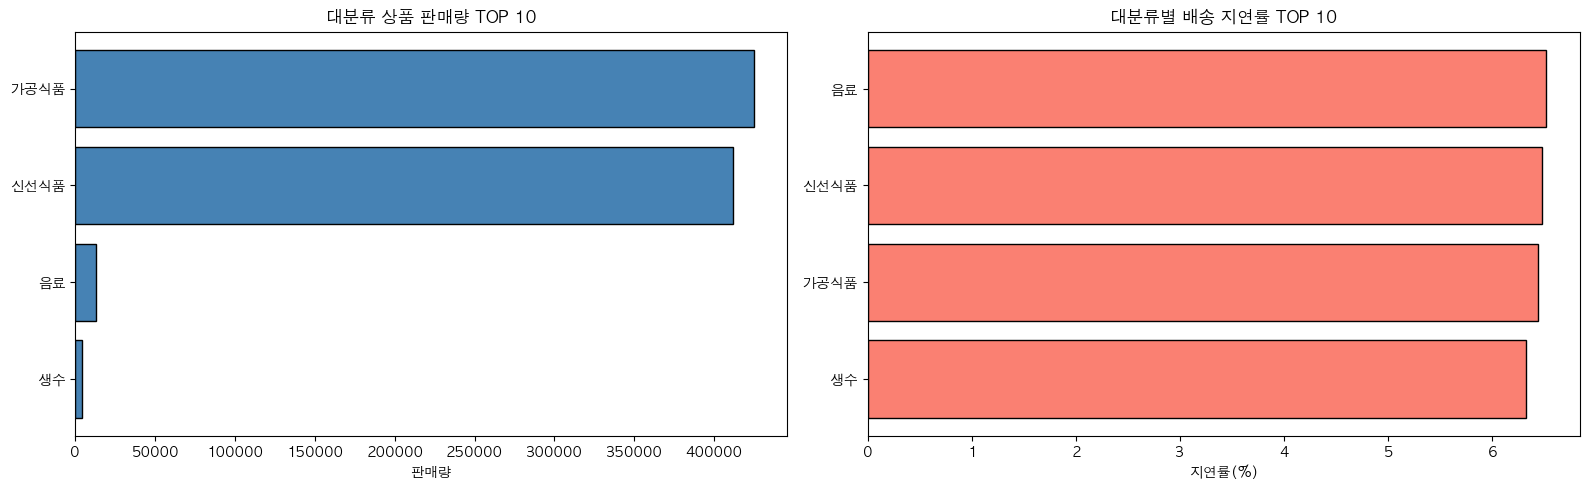

In [21]:
# 9. 상품 카테고리 분석
print("\n" + "=" * 50)
print("📌 상품 카테고리 분석")
print("=" * 50)

# 대분류 상품
print("\n✓ 대분류 상품 판매량 TOP 10:")
top_large = df['ItemLargeName'].value_counts().head(10)
print(top_large)

# 중분류 상품
print("\n✓ 중분류 상품 판매량 TOP 10:")
top_middle = df['ItemMiddleName'].value_counts().head(10)
print(top_middle)

# 상품별 지연율
print("\n✓ 대분류별 배송 지연률 TOP 10:")
large_late = df.groupby('ItemLargeName')['IsLate'].apply(lambda x: (x == 1).sum() / len(x) * 100).sort_values(ascending=False)
print(large_late.head(10).round(2))

# 상품 카테고리 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 판매량 상위 10개 상품
top_10_items = df['ItemLargeName'].value_counts().head(10)
axes[0].barh(range(len(top_10_items)), top_10_items.values, color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(top_10_items)))
axes[0].set_yticklabels(top_10_items.index)
axes[0].set_xlabel('판매량')
axes[0].set_title('대분류 상품 판매량 TOP 10', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# 상품별 지연율 상위 10개
top_10_late_items = large_late.head(10)
axes[1].barh(range(len(top_10_late_items)), top_10_late_items.values, color='salmon', edgecolor='black')
axes[1].set_yticks(range(len(top_10_late_items)))
axes[1].set_yticklabels(top_10_late_items.index)
axes[1].set_xlabel('지연률(%)')
axes[1].set_title('대분류별 배송 지연률 TOP 10', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 📊 해석

**상품 카테고리 분석:**
- **판매 상위 카테고리**(신선 과일, 해산물 등): 고객 선호도 높음
- **지연율 상위 카테고리**: 판매량 상위와 **다른 카테고리들** → 특정 카테고리의 배송 어려움 시사
- **해석**: 무거운 상품이나 특수 배송 필요 카테고리에서 지연 발생 가능
- **개선 방향**: 지연율 높은 카테고리에 대한 **배송 인프라 확대** 고려

# 고객별 1회 주문 파생변수 생성

## 개요
현재 데이터는 **행 = 주문 라인 아이템** 구조(854,101행)입니다.
- 하나의 `idOrder`에 여러 상품이 포함됨
- **1회 주문 = 동일한 `idOrder`** (이미 고객+시간 단위로 묶여 있음)
- 고객별 구매 패턴(1회 주문 단위) 분석을 위한 파생변수 생성

In [22]:
# Step 1: 주문 단위(idOrder) 집계
print("=" * 60)
print("Step 1: 주문 단위(idOrder) 집계")
print("=" * 60)

order_stats = df.groupby(['idUser', 'idOrder']).agg(
    order_amount=('Price', 'sum'),    # 1회당 주문금액
    order_item_count=('Price', 'count')  # 1회당 주문개수
).reset_index()

print(f"\n✓ 주문 통계 크기: {order_stats.shape}")
print(f"✓ 고유 고객 수: {order_stats['idUser'].nunique()}")
print(f"✓ 고유 주문 수: {order_stats['idOrder'].nunique()}")
print(f"\n주문 금액 및 개수 분포:")
print(order_stats[['order_amount', 'order_item_count']].describe())

Step 1: 주문 단위(idOrder) 집계

✓ 주문 통계 크기: (171029, 4)
✓ 고유 고객 수: 3000
✓ 고유 주문 수: 171029

주문 금액 및 개수 분포:
        order_amount  order_item_count
count  171029.000000     171029.000000
mean    76974.451409          4.993896
std     35243.193263          1.789430
min      1160.000000          1.000000
25%     51420.000000          4.000000
50%     73770.000000          5.000000
75%     98990.000000          6.000000
max    336130.000000         20.000000


In [23]:
# Step 2: 고객 단위(idUser) 집계 — 파생변수 생성
print("\n" + "=" * 60)
print("Step 2: 고객 단위(idUser) 집계 — 파생변수 생성")
print("=" * 60)

customer_derived = order_stats.groupby('idUser').agg(
    avg_order_amount=('order_amount', 'mean'),        # 고객별 평균 1회당 주문금액
    avg_order_item_count=('order_item_count', 'mean'),# 고객별 평균 1회당 주문개수
    total_order_count=('idOrder', 'count'),           # 총 주문 횟수
    total_spend=('order_amount', 'sum'),              # 총 누적 구매금액
    max_order_amount=('order_amount', 'max'),         # 최대 1회 주문금액
    min_order_amount=('order_amount', 'min'),         # 최소 1회 주문금액
).reset_index()

# 추가 파생변수
customer_derived['order_amount_std'] = order_stats.groupby('idUser')['order_amount'].std().reset_index()['order_amount']
customer_derived['order_amount_range'] = customer_derived['max_order_amount'] - customer_derived['min_order_amount']

print(f"\n✓ 고객 파생변수 크기: {customer_derived.shape}")
print(f"✓ 생성된 변수:")
print(f"  - avg_order_amount: 평균 1회당 주문금액")
print(f"  - avg_order_item_count: 평균 1회당 주문개수")
print(f"  - total_order_count: 총 주문 횟수")
print(f"  - total_spend: 총 누적 구매금액")
print(f"  - max_order_amount: 최대 1회 주문금액")
print(f"  - min_order_amount: 최소 1회 주문금액")
print(f"  - order_amount_std: 주문금액 표준편차")
print(f"  - order_amount_range: 주문금액 범위(최대-최소)")

print(f"\n고객별 파생변수 분포:")
print(customer_derived.describe())


Step 2: 고객 단위(idUser) 집계 — 파생변수 생성

✓ 고객 파생변수 크기: (3000, 9)
✓ 생성된 변수:
  - avg_order_amount: 평균 1회당 주문금액
  - avg_order_item_count: 평균 1회당 주문개수
  - total_order_count: 총 주문 횟수
  - total_spend: 총 누적 구매금액
  - max_order_amount: 최대 1회 주문금액
  - min_order_amount: 최소 1회 주문금액
  - order_amount_std: 주문금액 표준편차
  - order_amount_range: 주문금액 범위(최대-최소)

고객별 파생변수 분포:
       avg_order_amount  avg_order_item_count  total_order_count  \
count       3000.000000           3000.000000        3000.000000   
mean       77429.636837              5.016592          57.009667   
std         6725.503464              0.351588          12.990041   
min        55575.750000              3.971831           9.000000   
25%        72801.561668              4.780000          49.000000   
50%        77351.911765              5.022739          60.000000   
75%        81676.307998              5.235294          66.000000   
max       111365.200000              6.640000          90.000000   

        total_spend  max_order_amou

In [24]:
# Step 3: 원본 df에 파생변수 병합
print("\n" + "=" * 60)
print("Step 3: 원본 df에 파생변수 병합")
print("=" * 60)

df = df.merge(customer_derived, on='idUser', how='left')

print(f"\n✓ 병합 후 df 크기: {df.shape}")
print(f"✓ df 컬럼 수: {len(df.columns)}")
print(f"\n병합된 df 샘플(첫 5행, 파생변수만):")
print(df[['idUser', 'avg_order_amount', 'avg_order_item_count', 'total_order_count', 'total_spend', 'max_order_amount', 'min_order_amount']].head())


Step 3: 원본 df에 파생변수 병합

✓ 병합 후 df 크기: (854101, 43)
✓ df 컬럼 수: 43

병합된 df 샘플(첫 5행, 파생변수만):
   idUser  avg_order_amount  avg_order_item_count  total_order_count  \
0  U10001      78478.115942              5.028986                 69   
1  U10001      78478.115942              5.028986                 69   
2  U10001      78478.115942              5.028986                 69   
3  U10001      78478.115942              5.028986                 69   
4  U10001      78478.115942              5.028986                 69   

   total_spend  max_order_amount  min_order_amount  
0      5414990            152430             13420  
1      5414990            152430             13420  
2      5414990            152430             13420  
3      5414990            152430             13420  
4      5414990            152430             13420  


In [25]:
df.head()

,idUser,idOrder,OrderDT,ItemCode,Price,DeliveryDT,OrderYear,OrderMonth,OrderDay,OrderHour,...,AgeGroup,PriceRange,avg_order_amount,avg_order_item_count,total_order_count,total_spend,max_order_amount,min_order_amount,order_amount_std,order_amount_range
0,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M17-S0530-1024,33310,2023-01-07 06:24:00,2023,1,6,17,...,20,"(33240.0, 41310.0]",78478.115942,5.028986,69,5414990,152430,13420,34811.67596,139010
1,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M21-S0540-1082,3780,2023-01-07 06:24:00,2023,1,6,17,...,20,"(919.65, 9030.0]",78478.115942,5.028986,69,5414990,152430,13420,34811.67596,139010
2,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L1-M15-S0140-1311,22520,2023-01-07 06:24:00,2023,1,6,17,...,20,"(17100.0, 25170.0]",78478.115942,5.028986,69,5414990,152430,13420,34811.67596,139010
3,U10001,U10001-O2023-1002,2023-01-06 17:08:51,L4-M12-S0350-1035,21630,2023-01-07 06:24:00,2023,1,6,17,...,20,"(17100.0, 25170.0]",78478.115942,5.028986,69,5414990,152430,13420,34811.67596,139010
4,U10001,U10001-O2023-1003,2023-01-13 16:50:14,L4-M12-S0640-1057,11700,2023-01-14 06:28:00,2023,1,13,16,...,20,"(9030.0, 17100.0]",78478.115942,5.028986,69,5414990,152430,13420,34811.67596,139010


In [26]:
# Step 4: 검증 및 샘플 분석
print("\n" + "=" * 60)
print("Step 4: 검증 및 샘플 분석")
print("=" * 60)

# 특정 고객(U10001) 샘플 검증
sample_customer = 'U10001'
sample_orders = order_stats[order_stats['idUser'] == sample_customer]
sample_customer_stats = customer_derived[customer_derived['idUser'] == sample_customer]

print(f"\n✓ 샘플 고객({sample_customer}) 검증:")
print(f"\n  주문 목록:")
print(sample_orders)
print(f"\n  파생변수:")
print(sample_customer_stats)

# 수동 검증
if len(sample_orders) > 0:
    manual_avg_amount = sample_orders['order_amount'].mean()
    manual_total_count = len(sample_orders)
    manual_total_spend = sample_orders['order_amount'].sum()
    
    stored_avg_amount = sample_customer_stats['avg_order_amount'].values[0]
    stored_total_count = sample_customer_stats['total_order_count'].values[0]
    stored_total_spend = sample_customer_stats['total_spend'].values[0]
    
    print(f"\n  검증 결과:")
    print(f"  - 평균 주문금액: 계산={manual_avg_amount:.2f}, 저장={stored_avg_amount:.2f} → {'✓' if abs(manual_avg_amount - stored_avg_amount) < 0.01 else '✗'}")
    print(f"  - 주문 횟수: 계산={manual_total_count}, 저장={stored_total_count} → {'✓' if manual_total_count == stored_total_count else '✗'}")
    print(f"  - 누적 구매금액: 계산={manual_total_spend:.2f}, 저장={stored_total_spend:.2f} → {'✓' if abs(manual_total_spend - stored_total_spend) < 0.01 else '✗'}")


Step 4: 검증 및 샘플 분석

✓ 샘플 고객(U10001) 검증:

  주문 목록:
    idUser            idOrder  order_amount  order_item_count
0   U10001  U10001-O2023-1001         92900                 7
1   U10001  U10001-O2023-1002         81240                 4
2   U10001  U10001-O2023-1003         60350                 4
3   U10001  U10001-O2023-1004         66370                 4
4   U10001  U10001-O2023-1005        142840                 7
..     ...                ...           ...               ...
64  U10001  U10001-O2025-1014         62810                 6
65  U10001  U10001-O2025-1015         67610                 4
66  U10001  U10001-O2025-1016        120430                 6
67  U10001  U10001-O2025-1017         72690                 3
68  U10001  U10001-O2025-1018        130790                 6

[69 rows x 4 columns]

  파생변수:
   idUser  avg_order_amount  avg_order_item_count  total_order_count  \
0  U10001      78478.115942              5.028986                 69   

   total_spend  max_order_am


Step 5: 파생변수 시각화 및 최종 요약


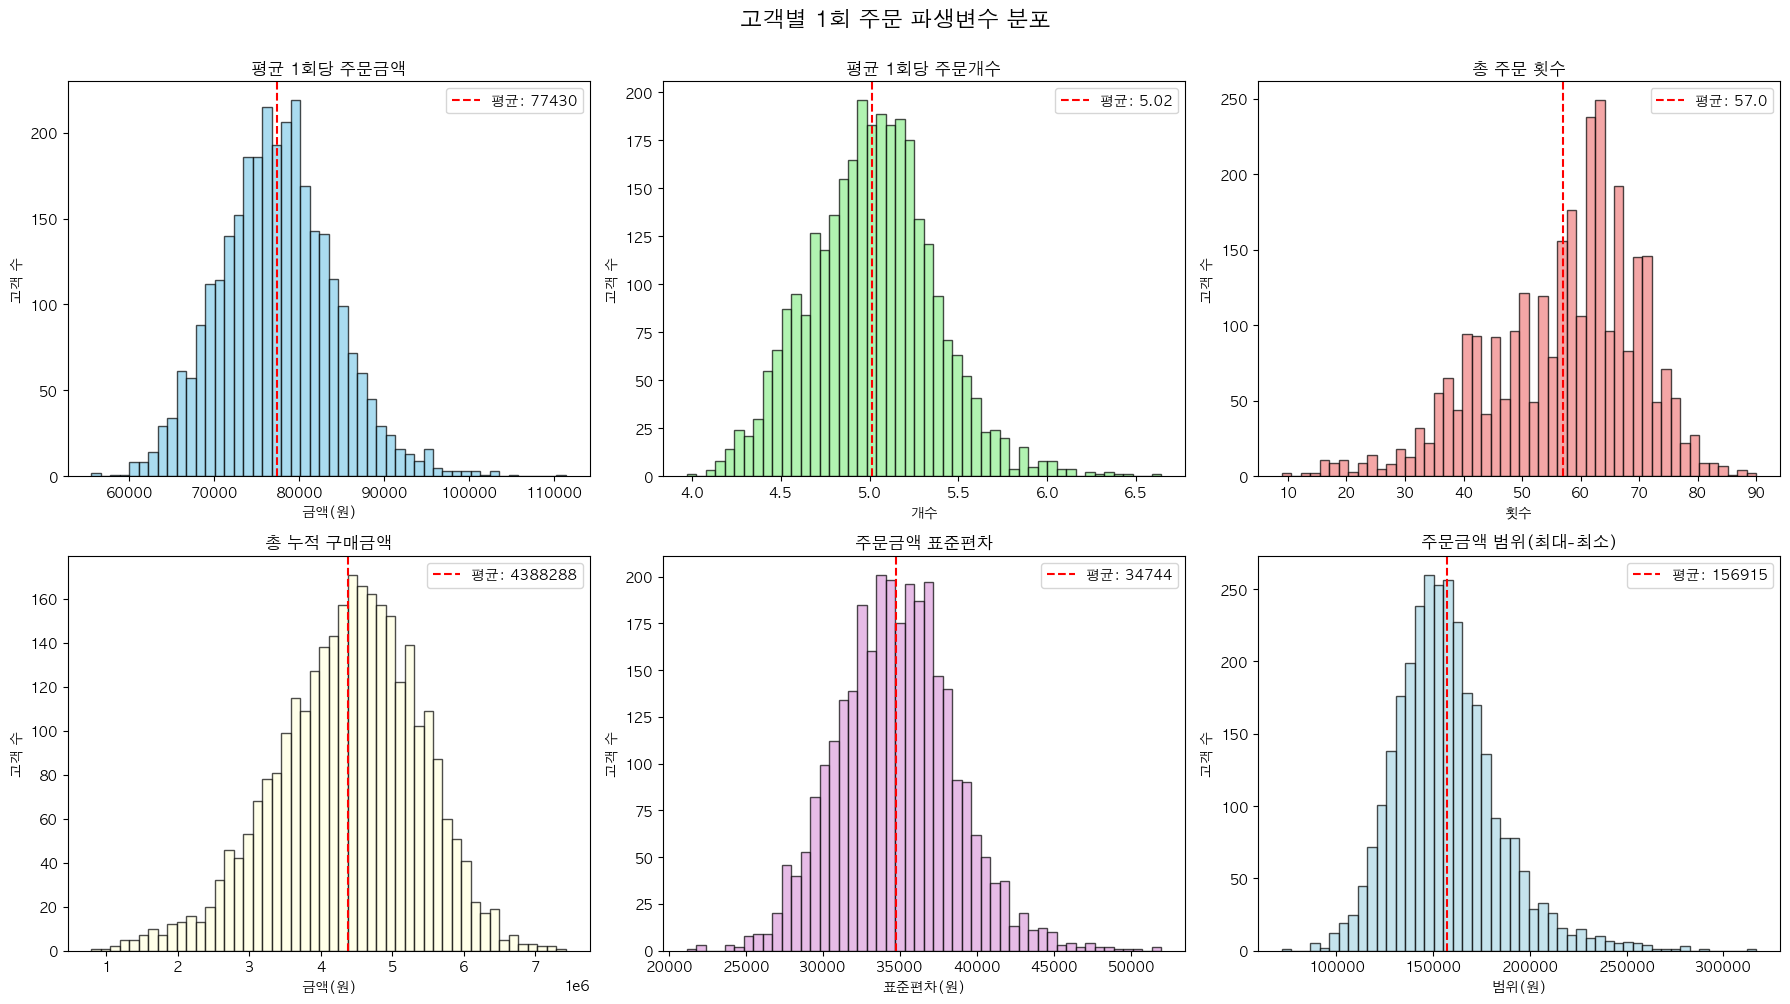


✓ 최종 요약:
  - 총 고객 수: 3000
  - 총 주문 수: 171029
  - 고객당 평균 주문 횟수: 57.01
  - 전체 누적 구매금액: ₩13,164,863,450
  - 고객당 평균 누적 구매금액: ₩4,388,288
  - 평균 1회당 주문금액: ₩77,430
  - 평균 1회당 주문개수: 5.02개


In [27]:
# Step 5: 파생변수 시각화 및 최종 요약
print("\n" + "=" * 60)
print("Step 5: 파생변수 시각화 및 최종 요약")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('고객별 1회 주문 파생변수 분포', fontsize=16, fontweight='bold', y=1.00)

# 1. 평균 주문금액
axes[0, 0].hist(customer_derived['avg_order_amount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('평균 1회당 주문금액')
axes[0, 0].set_xlabel('금액(원)')
axes[0, 0].set_ylabel('고객 수')
axes[0, 0].axvline(customer_derived['avg_order_amount'].mean(), color='red', linestyle='--', label=f'평균: {customer_derived["avg_order_amount"].mean():.0f}')
axes[0, 0].legend()

# 2. 평균 주문개수
axes[0, 1].hist(customer_derived['avg_order_item_count'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('평균 1회당 주문개수')
axes[0, 1].set_xlabel('개수')
axes[0, 1].set_ylabel('고객 수')
axes[0, 1].axvline(customer_derived['avg_order_item_count'].mean(), color='red', linestyle='--', label=f'평균: {customer_derived["avg_order_item_count"].mean():.2f}')
axes[0, 1].legend()

# 3. 총 주문 횟수
axes[0, 2].hist(customer_derived['total_order_count'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('총 주문 횟수')
axes[0, 2].set_xlabel('횟수')
axes[0, 2].set_ylabel('고객 수')
axes[0, 2].axvline(customer_derived['total_order_count'].mean(), color='red', linestyle='--', label=f'평균: {customer_derived["total_order_count"].mean():.1f}')
axes[0, 2].legend()

# 4. 총 누적 구매금액
axes[1, 0].hist(customer_derived['total_spend'], bins=50, color='lightyellow', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('총 누적 구매금액')
axes[1, 0].set_xlabel('금액(원)')
axes[1, 0].set_ylabel('고객 수')
axes[1, 0].axvline(customer_derived['total_spend'].mean(), color='red', linestyle='--', label=f'평균: {customer_derived["total_spend"].mean():.0f}')
axes[1, 0].legend()

# 5. 주문금액 표준편차
axes[1, 1].hist(customer_derived['order_amount_std'].dropna(), bins=50, color='plum', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('주문금액 표준편차')
axes[1, 1].set_xlabel('표준편차(원)')
axes[1, 1].set_ylabel('고객 수')
axes[1, 1].axvline(customer_derived['order_amount_std'].mean(), color='red', linestyle='--', label=f'평균: {customer_derived["order_amount_std"].mean():.0f}')
axes[1, 1].legend()

# 6. 주문금액 범위
axes[1, 2].hist(customer_derived['order_amount_range'], bins=50, color='lightblue', edgecolor='black', alpha=0.7)
axes[1, 2].set_title('주문금액 범위(최대-최소)')
axes[1, 2].set_xlabel('범위(원)')
axes[1, 2].set_ylabel('고객 수')
axes[1, 2].axvline(customer_derived['order_amount_range'].mean(), color='red', linestyle='--', label=f'평균: {customer_derived["order_amount_range"].mean():.0f}')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print("\n✓ 최종 요약:")
print(f"  - 총 고객 수: {len(customer_derived)}")
print(f"  - 총 주문 수: {order_stats.shape[0]}")
print(f"  - 고객당 평균 주문 횟수: {customer_derived['total_order_count'].mean():.2f}")
print(f"  - 전체 누적 구매금액: ₩{customer_derived['total_spend'].sum():,.0f}")
print(f"  - 고객당 평균 누적 구매금액: ₩{customer_derived['total_spend'].mean():,.0f}")
print(f"  - 평균 1회당 주문금액: ₩{customer_derived['avg_order_amount'].mean():,.0f}")
print(f"  - 평균 1회당 주문개수: {customer_derived['avg_order_item_count'].mean():.2f}개")

# 고객별 파생변수 + 배송지연 통합

고객별 파생변수에 배송지연(IsLate) 정보를 추가하여 고객별 배송 신뢰도 지표 생성

In [28]:
# 고객별 배송지연 정보 집계
print("=" * 60)
print("고객별 배송지연 정보 집계")
print("=" * 60)

customer_delivery = df.groupby('idUser').agg(
    delay_count=('IsLate', 'sum'),        # 지연된 주문 건수
    total_transactions=('IsLate', 'count') # 전체 주문 건수
).reset_index()

# 배송지연율 계산
customer_delivery['delay_rate'] = (customer_delivery['delay_count'] / customer_delivery['total_transactions'] * 100).round(2)
customer_delivery['on_time_count'] = customer_delivery['total_transactions'] - customer_delivery['delay_count']

print(f"\n✓ 고객별 배송지연 정보 크기: {customer_delivery.shape}")
print(f"\n고객별 배송지연 정보 샘플:")
print(customer_delivery.head(10))

print(f"\n배송지연 통계:")
print(customer_delivery[['delay_count', 'delay_rate', 'on_time_count']].describe())

고객별 배송지연 정보 집계

✓ 고객별 배송지연 정보 크기: (3000, 5)

고객별 배송지연 정보 샘플:
   idUser  delay_count  total_transactions  delay_rate  on_time_count
0  U10001           60                 347       17.29            287
1  U10002           37                 269       13.75            232
2  U10003            0                 289        0.00            289
3  U10004            7                 161        4.35            154
4  U10005           13                 371        3.50            358
5  U10006            8                 351        2.28            343
6  U10007           25                 376        6.65            351
7  U10008           32                 327        9.79            295
8  U10009           11                 124        8.87            113
9  U10010            8                 136        5.88            128

배송지연 통계:
       delay_count   delay_rate  on_time_count
count  3000.000000  3000.000000    3000.000000
mean     18.384667     6.491157     266.315667
std      11.166838

In [29]:
# 고객별 파생변수와 배송지연 정보 통합
print("\n" + "=" * 60)
print("고객별 파생변수 + 배송지연 통합")
print("=" * 60)

# customer_derived와 customer_delivery 병합
customer_final = customer_derived.merge(customer_delivery[['idUser', 'delay_count', 'delay_rate', 'on_time_count']], 
                                        on='idUser', 
                                        how='left')

print(f"\n✓ 최종 고객별 통합 데이터 크기: {customer_final.shape}")
print(f"✓ 컬럼 수: {len(customer_final.columns)}")
print(f"\n✓ 최종 컬럼 목록:")
for i, col in enumerate(customer_final.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n최종 데이터 샘플 (첫 10행):")
print(customer_final.head(10))


고객별 파생변수 + 배송지연 통합

✓ 최종 고객별 통합 데이터 크기: (3000, 12)
✓ 컬럼 수: 12

✓ 최종 컬럼 목록:
   1. idUser
   2. avg_order_amount
   3. avg_order_item_count
   4. total_order_count
   5. total_spend
   6. max_order_amount
   7. min_order_amount
   8. order_amount_std
   9. order_amount_range
  10. delay_count
  11. delay_rate
  12. on_time_count

최종 데이터 샘플 (첫 10행):
   idUser  avg_order_amount  avg_order_item_count  total_order_count  \
0  U10001      78478.115942              5.028986                 69   
1  U10002      74466.981132              5.075472                 53   
2  U10003      89794.339623              5.452830                 53   
3  U10004      75709.696970              4.878788                 33   
4  U10005      71330.384615              4.756410                 78   
5  U10006      80902.142857              5.014286                 70   
6  U10007      80123.802817              5.295775                 71   
7  U10008      82596.769231              5.030769                 65   
8 

In [30]:
# 고객별 통합 데이터 검증 및 분석
print("\n" + "=" * 60)
print("고객별 통합 데이터 검증 및 분석")
print("=" * 60)

print(f"\n✓ 행 개수 확인:")
print(f"  - customer_final 행 수: {len(customer_final)}")
print(f"  - 고유 고객 수(idUser): {customer_final['idUser'].nunique()}")
print(f"  - 예상 고객 수: 3,000 → 실제: {len(customer_final)} {'✓' if len(customer_final) == 3000 else '✗'}")

print(f"\n✓ 배송지연 통계:")
print(f"  - 평균 지연 건수: {customer_final['delay_count'].mean():.2f}건")
print(f"  - 평균 지연율: {customer_final['delay_rate'].mean():.2f}%")
print(f"  - 최대 지연율: {customer_final['delay_rate'].max():.2f}%")
print(f"  - 최소 지연율: {customer_final['delay_rate'].min():.2f}%")

print(f"\n✓ 지연율 분포:")
delay_distribution = customer_final['delay_rate'].describe()
print(delay_distribution)

# 샘플 고객 검증 (U10001)
sample_customer = customer_final[customer_final['idUser'] == 'U10001']
if len(sample_customer) > 0:
    print(f"\n✓ 샘플 고객(U10001) 검증:")
    print(f"  - 평균 주문금액: ₩{sample_customer['avg_order_amount'].values[0]:,.0f}")
    print(f"  - 총 주문 횟수: {sample_customer['total_order_count'].values[0]:.0f}회")
    print(f"  - 지연 건수: {sample_customer['delay_count'].values[0]:.0f}건")
    print(f"  - 지연율: {sample_customer['delay_rate'].values[0]:.2f}%")


고객별 통합 데이터 검증 및 분석

✓ 행 개수 확인:
  - customer_final 행 수: 3000
  - 고유 고객 수(idUser): 3000
  - 예상 고객 수: 3,000 → 실제: 3000 ✓

✓ 배송지연 통계:
  - 평균 지연 건수: 18.38건
  - 평균 지연율: 6.49%
  - 최대 지연율: 26.80%
  - 최소 지연율: 0.00%

✓ 지연율 분포:
count    3000.000000
mean        6.491157
std         3.828253
min         0.000000
25%         3.740000
50%         6.090000
75%         8.870000
max        26.800000
Name: delay_rate, dtype: float64

✓ 샘플 고객(U10001) 검증:
  - 평균 주문금액: ₩78,478
  - 총 주문 횟수: 69회
  - 지연 건수: 60건
  - 지연율: 17.29%



고객별 통합 데이터 시각화


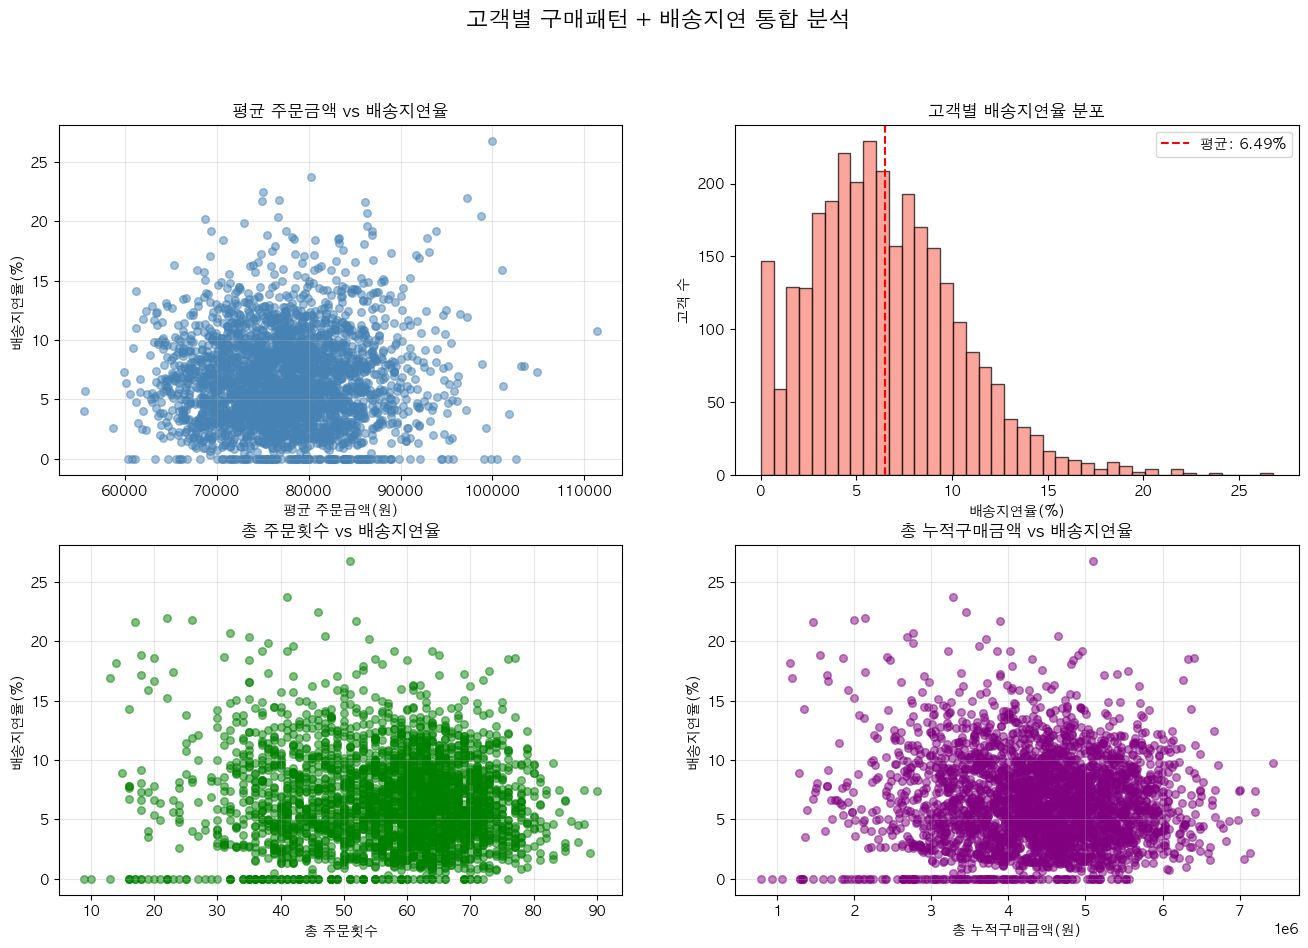

In [31]:
# 고객별 통합 데이터 시각화
print("\n" + "=" * 60)
print("고객별 통합 데이터 시각화")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('고객별 구매패턴 + 배송지연 통합 분석', fontsize=16, fontweight='bold', y=0.995)

# 1. 주문금액 vs 지연율 산점도
axes[0, 0].scatter(customer_final['avg_order_amount'], customer_final['delay_rate'], alpha=0.5, s=30, color='steelblue')
axes[0, 0].set_title('평균 주문금액 vs 배송지연율')
axes[0, 0].set_xlabel('평균 주문금액(원)')
axes[0, 0].set_ylabel('배송지연율(%)')
axes[0, 0].grid(True, alpha=0.3)

# 2. 지연율 분포 히스토그램
axes[0, 1].hist(customer_final['delay_rate'], bins=40, color='salmon', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('고객별 배송지연율 분포')
axes[0, 1].set_xlabel('배송지연율(%)')
axes[0, 1].set_ylabel('고객 수')
axes[0, 1].axvline(customer_final['delay_rate'].mean(), color='red', linestyle='--', label=f'평균: {customer_final["delay_rate"].mean():.2f}%')
axes[0, 1].legend()

# 3. 주문횟수 vs 지연율 산점도
axes[1, 0].scatter(customer_final['total_order_count'], customer_final['delay_rate'], alpha=0.5, s=30, color='green')
axes[1, 0].set_title('총 주문횟수 vs 배송지연율')
axes[1, 0].set_xlabel('총 주문횟수')
axes[1, 0].set_ylabel('배송지연율(%)')
axes[1, 0].grid(True, alpha=0.3)

# 4. 누적구매금액 vs 지연율 산점도
axes[1, 1].scatter(customer_final['total_spend'], customer_final['delay_rate'], alpha=0.5, s=30, color='purple')
axes[1, 1].set_title('총 누적구매금액 vs 배송지연율')
axes[1, 1].set_xlabel('총 누적구매금액(원)')
axes[1, 1].set_ylabel('배송지연율(%)')
axes[1, 1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig('customer_final_analysis.png', dpi=300, bbox_inches='tight')
# print("✓ 시각화 저장: customer_final_analysis.png")
# plt.close()

# # 최종 데이터 저장
# customer_final.to_csv('customer_final_integrated.csv', index=False, encoding='cp949')
# print("✓ 최종 고객별 통합 데이터 저장: customer_final_integrated.csv")

# print("\n✅ 고객별 파생변수 + 배송지연 통합 완료!")
# print(f"   → {len(customer_final)}행 × {len(customer_final.columns)}열")

In [45]:
from scipy import stats

print("=" * 60)
print("배송지연율 상관관계 통계 검증 (Pearson)")
print("=" * 60)

variables = {
    '평균 주문금액':    customer_final['avg_order_amount'],
    '총 주문횟수':      customer_final['total_order_count'],
    '총 누적구매금액':  customer_final['total_spend'],
}

for name, col in variables.items():
    mask = col.notna() & customer_final['delay_rate'].notna()
    x, y = col[mask], customer_final['delay_rate'][mask]
    
    r_p, p_p = stats.pearsonr(x, y)
    
    print(f"\n[{name} vs 배송지연율]")
    print(f"  Pearson  r = {r_p:.4f},  p-value = {p_p:.4f}  {'***' if p_p < 0.001 else '**' if p_p < 0.01 else '*' if p_p < 0.05 else 'ns'}")

print("\n유의수준: *** p<0.001  ** p<0.01  * p<0.05  ns: not significant")


배송지연율 상관관계 통계 검증 (Pearson)

[평균 주문금액 vs 배송지연율]
  Pearson  r = 0.0327,  p-value = 0.0736  ns

[총 주문횟수 vs 배송지연율]
  Pearson  r = -0.0455,  p-value = 0.0127  *

[총 누적구매금액 vs 배송지연율]
  Pearson  r = -0.0350,  p-value = 0.0555  ns

유의수준: *** p<0.001  ** p<0.01  * p<0.05  ns: not significant


In [46]:
from scipy import stats

print("=" * 60)
print("배송지연율 상관관계 통계 검증 (Spearman)")
print("=" * 60)

variables = {
    '평균 주문금액':    customer_final['avg_order_amount'],
    '총 주문횟수':      customer_final['total_order_count'],
    '총 누적구매금액':  customer_final['total_spend'],
}

for name, col in variables.items():
    mask = col.notna() & customer_final['delay_rate'].notna()
    x, y = col[mask], customer_final['delay_rate'][mask]
    
    r_s, p_s = stats.spearmanr(x, y)
    
    print(f"\n[{name} vs 배송지연율]")
    print(f"  Spearman r = {r_s:.4f},  p-value = {p_s:.4f}  {'***' if p_s < 0.001 else '**' if p_s < 0.01 else '*' if p_s < 0.05 else 'ns'}")

print("\n유의수준: *** p<0.001  ** p<0.01  * p<0.05  ns: not significant")


배송지연율 상관관계 통계 검증 (Spearman)

[평균 주문금액 vs 배송지연율]
  Spearman r = 0.0104,  p-value = 0.5677  ns

[총 주문횟수 vs 배송지연율]
  Spearman r = -0.0185,  p-value = 0.3123  ns

[총 누적구매금액 vs 배송지연율]
  Spearman r = -0.0138,  p-value = 0.4514  ns

유의수준: *** p<0.001  ** p<0.01  * p<0.05  ns: not significant


## 추가 분석: 주문 단위 지연율 및 고객 세분화

In [33]:
# 주문 단위 지연율 계산 (vs 현재의 라인아이템 기준 지연율)
print("=" * 60)
print("주문 단위 지연율 분석")
print("=" * 60)

# 주문별 지연 여부 판단 (해당 주문의 모든 라인아이템 중 1개 이상 지연되면 '지연 주문')
order_delay_info = df.groupby(['idUser', 'idOrder']).agg(
    has_delay=('IsLate', 'max')  # 주문 내 최소 1개 아이템 지연 시 1
).reset_index()

# 고객별 지연 주문 수 계산
customer_order_delay = order_delay_info.groupby('idUser').agg(
    delayed_order_count=('has_delay', 'sum'),
).reset_index()

# total_order_count와 병합하여 주문 기준 지연율 계산
customer_order_delay = customer_order_delay.merge(
    customer_final[['idUser', 'total_order_count']], 
    on='idUser', 
    how='left'
)
customer_order_delay['order_delay_rate'] = (
    customer_order_delay['delayed_order_count'] / customer_order_delay['total_order_count'] * 100
).round(2)

print(f"\n✓ 주문별 지연 정보 계산 완료")
print(f"\n주문 단위 지연율 샘플 (상위 10명):")
print(customer_order_delay.head(10))

# 라인아이템 기준 지연율 vs 주문 기준 지연율 비교
comparison = customer_final[['idUser', 'delay_rate', 'total_order_count']].merge(
    customer_order_delay[['idUser', 'order_delay_rate']], 
    on='idUser'
)

print(f"\n라인아이템 기준 vs 주문 기준 지연율 비교:")
print(f"  라인아이템 기준 지연율: 평균={comparison['delay_rate'].mean():.2f}%, 중앙값={comparison['delay_rate'].median():.2f}%")
print(f"  주문 기준 지연율: 평균={comparison['order_delay_rate'].mean():.2f}%, 중앙값={comparison['order_delay_rate'].median():.2f}%")
print(f"\n  차이 (라인 - 주문): 평균={( comparison['delay_rate'] - comparison['order_delay_rate']).mean():.2f}%")

print(f"\n상관관계 분석:")
print(f"  - 라인아이템 지연율과 주문 지연율의 상관계수: {comparison['delay_rate'].corr(comparison['order_delay_rate']):.4f}")

# customer_final에 주문 기준 지연율 추가
customer_final = customer_final.merge(
    customer_order_delay[['idUser', 'order_delay_rate']], 
    on='idUser', 
    how='left'
)
print(f"\n✓ customer_final에 'order_delay_rate' 컬럼 추가 (총 {len(customer_final.columns)} 컬럼)")

주문 단위 지연율 분석

✓ 주문별 지연 정보 계산 완료

주문 단위 지연율 샘플 (상위 10명):
   idUser  delayed_order_count  total_order_count  order_delay_rate
0  U10001                   10                 69             14.49
1  U10002                    7                 53             13.21
2  U10003                    0                 53              0.00
3  U10004                    2                 33              6.06
4  U10005                    3                 78              3.85
5  U10006                    2                 70              2.86
6  U10007                    4                 71              5.63
7  U10008                    6                 65              9.23
8  U10009                    3                 25             12.00
9  U10010                    2                 30              6.67

라인아이템 기준 vs 주문 기준 지연율 비교:
  라인아이템 기준 지연율: 평균=6.49%, 중앙값=6.09%
  주문 기준 지연율: 평균=6.47%, 중앙값=6.15%

  차이 (라인 - 주문): 평균=0.02%

상관관계 분석:
  - 라인아이템 지연율과 주문 지연율의 상관계수: 0.9512

✓ customer_final에 'order_de


구매 행동 지표 × 배송지연율 상관관계 분석

[라인아이템 기준] delay_rate와의 상관계수:
delay_rate              1.000000
order_delay_rate        0.951157
min_order_amount        0.032710
avg_order_amount        0.032672
avg_order_item_count    0.023007
max_order_amount       -0.006041
order_amount_std       -0.011456
order_amount_range     -0.016045
total_spend            -0.034970
total_order_count      -0.045487

[주문 기준] order_delay_rate와의 상관계수:
delay_rate              0.951157
order_delay_rate        1.000000
min_order_amount        0.034669
avg_order_amount        0.029337
avg_order_item_count    0.020470
max_order_amount       -0.005142
order_amount_std       -0.013860
order_amount_range     -0.015798
total_spend            -0.036157
total_order_count      -0.044300


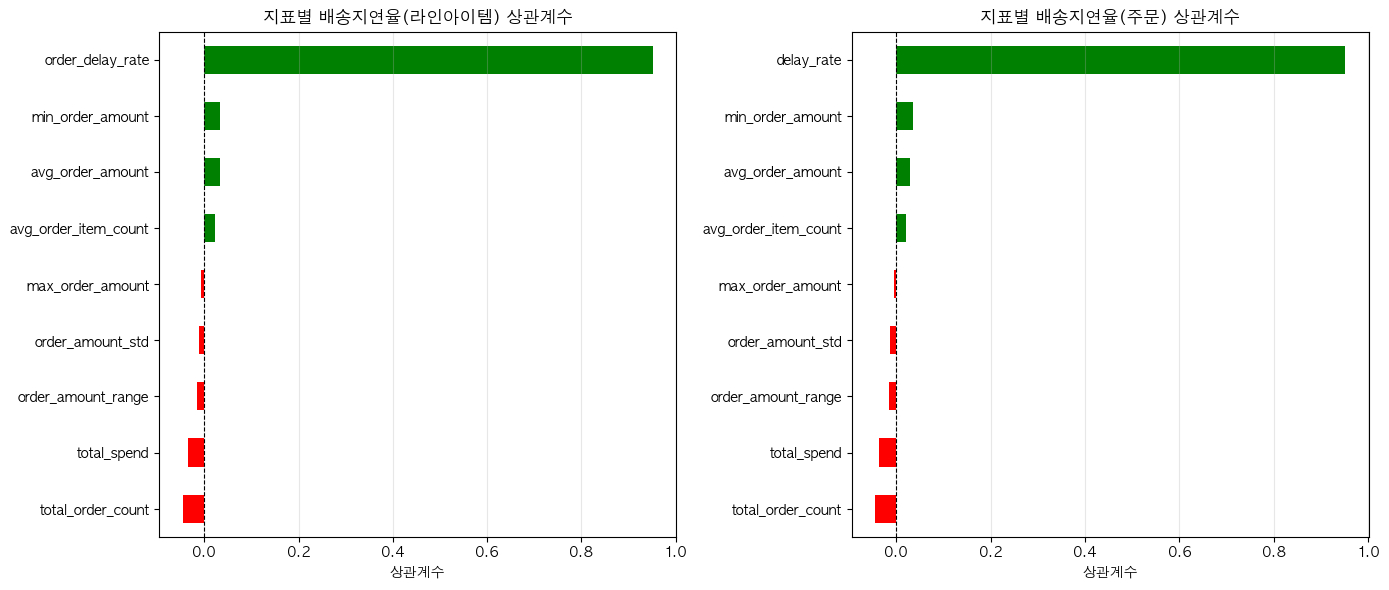


[주요 발견사항]
  ✓ 총 주문 횟수와 지연율의 상관계수: -0.0455
  ✓ 평균 주문금액과 지연율의 상관계수: 0.0327
  ✓ 총 누적 구매금액과 지연율의 상관계수: -0.0350

  → 지연율과 가장 강한 상관을 보이는 지표:
    1. order_delay_rate: 0.9512
    2. total_order_count: -0.0455
    3. total_spend: -0.0350


In [34]:
# 구매 행동 지표 × 배송지연율 상관관계 분석
print("\n" + "=" * 60)
print("구매 행동 지표 × 배송지연율 상관관계 분석")
print("=" * 60)

# 수치형 컬럼만 선택
numeric_cols = [
    'avg_order_amount', 'avg_order_item_count', 'total_order_count', 
    'total_spend', 'max_order_amount', 'min_order_amount', 
    'order_amount_std', 'order_amount_range', 
    'delay_rate', 'order_delay_rate'
]

correlation_matrix = customer_final[numeric_cols].corr()

# delay_rate와 관련된 상관계수만 추출
delay_correlations = correlation_matrix[['delay_rate', 'order_delay_rate']].sort_values('delay_rate', ascending=False)

print(f"\n[라인아이템 기준] delay_rate와의 상관계수:")
print(delay_correlations['delay_rate'].to_string())

print(f"\n[주문 기준] order_delay_rate와의 상관계수:")
print(delay_correlations['order_delay_rate'].to_string())

# 시각화 (2개 서브플롯)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. delay_rate와의 상관계수 시각화
ax1 = axes[0]
delay_corr_sorted = delay_correlations['delay_rate'].drop('delay_rate').sort_values()
colors_1 = ['red' if x < 0 else 'green' for x in delay_corr_sorted.values]
delay_corr_sorted.plot(kind='barh', ax=ax1, color=colors_1)
ax1.set_title('지표별 배송지연율(라인아이템) 상관계수', fontsize=12, fontweight='bold')
ax1.set_xlabel('상관계수')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax1.grid(axis='x', alpha=0.3)

# 2. order_delay_rate와의 상관계수 시각화
ax2 = axes[1]
order_corr_sorted = delay_correlations['order_delay_rate'].drop('order_delay_rate').sort_values()
colors_2 = ['red' if x < 0 else 'green' for x in order_corr_sorted.values]
order_corr_sorted.plot(kind='barh', ax=ax2, color=colors_2)
ax2.set_title('지표별 배송지연율(주문) 상관계수', fontsize=12, fontweight='bold')
ax2.set_xlabel('상관계수')
ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 주요 발견사항
print(f"\n[주요 발견사항]")
print(f"  ✓ 총 주문 횟수와 지연율의 상관계수: {correlation_matrix.loc['total_order_count', 'delay_rate']:.4f}")
print(f"  ✓ 평균 주문금액과 지연율의 상관계수: {correlation_matrix.loc['avg_order_amount', 'delay_rate']:.4f}")
print(f"  ✓ 총 누적 구매금액과 지연율의 상관계수: {correlation_matrix.loc['total_spend', 'delay_rate']:.4f}")

# 더 강한 상관 지표 찾기
strong_corr = delay_correlations['delay_rate'].drop('delay_rate').abs().sort_values(ascending=False).head(3)
print(f"\n  → 지연율과 가장 강한 상관을 보이는 지표:")
for idx, (name, value) in enumerate(strong_corr.items(), 1):
    corr_value = correlation_matrix.loc[name, 'delay_rate']
    print(f"    {idx}. {name}: {corr_value:.4f}")


주문 기준 배송지연율 상관계수 심층 분석


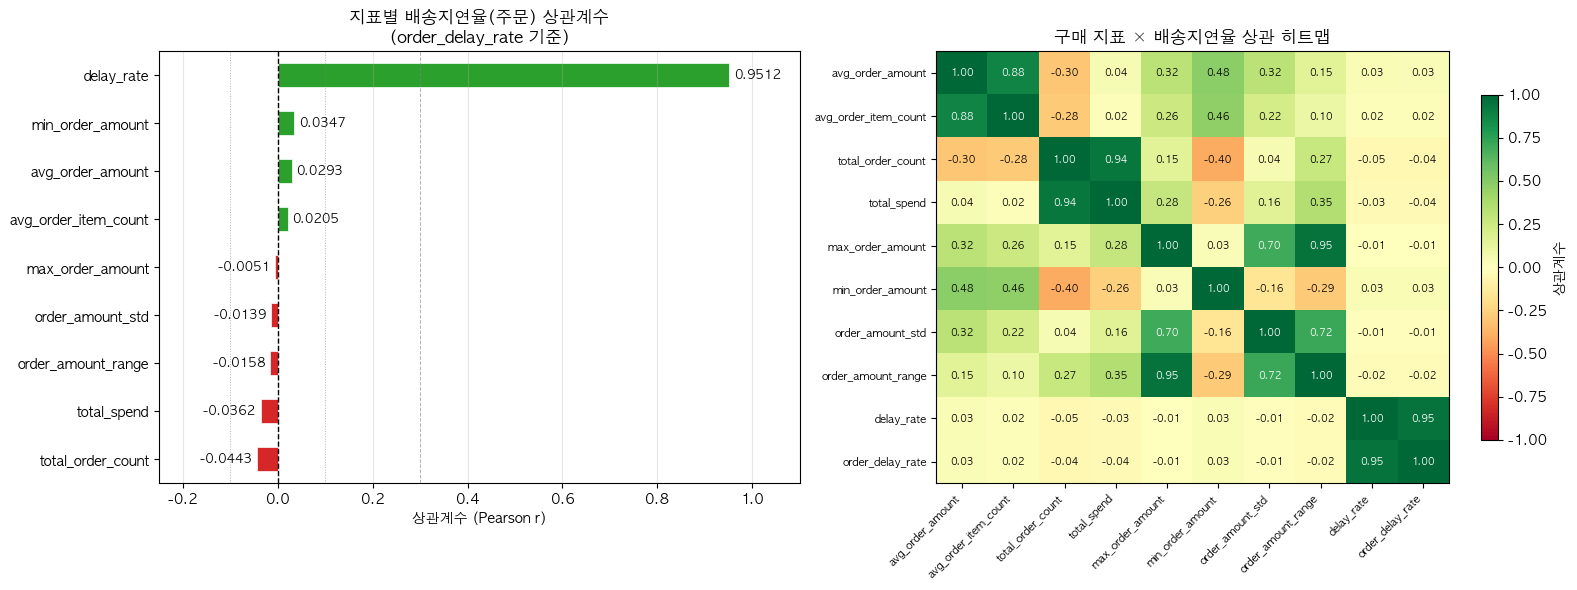


[order_delay_rate 상관계수 요약]
  delay_rate               : +0.9512  (강한 양적 상관)
  min_order_amount         : +0.0347  (약한 음적 상관)
  avg_order_amount         : +0.0293  (약한 음적 상관)
  avg_order_item_count     : +0.0205  (약한 음적 상관)
  max_order_amount         : -0.0051  (약한 음적 상관)
  order_amount_std         : -0.0139  (약한 음적 상관)
  order_amount_range       : -0.0158  (약한 음적 상관)
  total_spend              : -0.0362  (약한 음적 상관)
  total_order_count        : -0.0443  (약한 음적 상관)


In [35]:
# 주문 기준 배송지연율 상관계수 - 직관적 시각화 + 히트맵
print("\n" + "=" * 60)
print("주문 기준 배송지연율 상관계수 심층 분석")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. order_delay_rate 상관계수 - 값 레이블 포함한 직관적 bar chart
ax1 = axes[0]
order_corr = correlation_matrix['order_delay_rate'].drop('order_delay_rate').sort_values()
colors = ['#d62728' if x < 0 else '#2ca02c' for x in order_corr.values]
bars = order_corr.plot(kind='barh', ax=ax1, color=colors, edgecolor='white', linewidth=0.5)

# 값 레이블 추가
for i, (val, bar) in enumerate(zip(order_corr.values, ax1.patches)):
    x_pos = val + 0.01 if val >= 0 else val - 0.01
    ha = 'left' if val >= 0 else 'right'
    ax1.text(x_pos, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', ha=ha, fontsize=9, fontweight='bold')

ax1.set_title('지표별 배송지연율(주문) 상관계수\n(order_delay_rate 기준)', fontsize=12, fontweight='bold')
ax1.set_xlabel('상관계수 (Pearson r)')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax1.set_xlim(-0.25, 1.1)
ax1.grid(axis='x', alpha=0.3)

# 강도 기준선 표시
for threshold, style in [(0.1, ':'), (0.3, '--')]:
    ax1.axvline(x=threshold, color='gray', linestyle=style, linewidth=0.7, alpha=0.6)
    ax1.axvline(x=-threshold, color='gray', linestyle=style, linewidth=0.7, alpha=0.6)

# 2. 히트맵
ax2 = axes[1]
im = ax2.imshow(correlation_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

ax2.set_xticks(range(len(numeric_cols)))
ax2.set_yticks(range(len(numeric_cols)))
ax2.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=8)
ax2.set_yticklabels(numeric_cols, fontsize=8)

# 셀 값 표시
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        val = correlation_matrix.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax2.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax2, shrink=0.8, label='상관계수')
ax2.set_title('구매 지표 × 배송지연율 상관 히트맵', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 주요 해석
print(f"\n[order_delay_rate 상관계수 요약]")
order_corr_desc = correlation_matrix['order_delay_rate'].drop('order_delay_rate').sort_values(ascending=False)
for name, val in order_corr_desc.items():
    strength = "강한 양적" if val > 0.3 else ("약한 양적" if val > 0.1 else ("약한 음적" if val > -0.3 else "강한 음적"))
    print(f"  {name:25s}: {val:+.4f}  ({strength} 상관)")


구매 지표 × 배송지연율 통계적 유의성 검정
                  지표  상관계수(r)  p-value         유의성
   total_order_count  -0.0443   0.0152 유의함(p<0.05)
         total_spend  -0.0362   0.0477 유의함(p<0.05)
    min_order_amount   0.0347   0.0576     유의하지 않음
    avg_order_amount   0.0293   0.1082     유의하지 않음
avg_order_item_count   0.0205   0.2624     유의하지 않음
  order_amount_range  -0.0158   0.3871     유의하지 않음
    order_amount_std  -0.0139   0.4479     유의하지 않음
    max_order_amount  -0.0051   0.7783     유의하지 않음


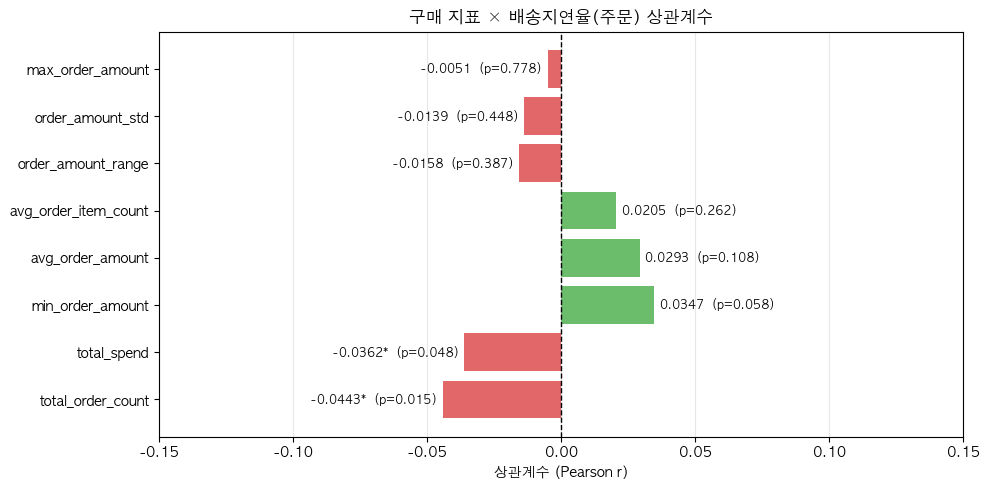


[결론]
  → 6개 지표: 통계적으로 유의하지 않음 (p ≥ 0.05)
  → 2개 지표: 유의한 상관 있음 (p < 0.05, 그러나 r값 자체가 매우 작아 실질적 의미 미미)
  → 결론: 고객의 구매 행동 패턴은 배송지연율과 선형적 관련성이 없음


In [36]:
from scipy import stats

# 구매 지표별 order_delay_rate 상관관계 통계적 유의성 검정
print("\n" + "=" * 60)
print("구매 지표 × 배송지연율 통계적 유의성 검정")
print("=" * 60)

purchase_cols = ['avg_order_amount', 'avg_order_item_count', 'total_order_count',
                 'total_spend', 'max_order_amount', 'min_order_amount',
                 'order_amount_std', 'order_amount_range']

results = []
for col in purchase_cols:
    mask = customer_final[[col, 'order_delay_rate']].dropna()
    r, p = stats.pearsonr(mask[col], mask['order_delay_rate'])
    results.append({'지표': col, '상관계수(r)': round(r, 4), 'p-value': round(p, 4),
                    '유의성': '유의함(p<0.05)' if p < 0.05 else '유의하지 않음'})

import pandas as pd
result_df = pd.DataFrame(results).sort_values('상관계수(r)', key=abs, ascending=False)
print(result_df.to_string(index=False))

# 시각화: r값과 p-value 함께 표시
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(result_df))
bars = ax.barh(result_df['지표'], result_df['상관계수(r)'],
               color=['#2ca02c' if v >= 0 else '#d62728' for v in result_df['상관계수(r)']],
               alpha=0.7)

for i, row in enumerate(result_df.itertuples()):
    sig_marker = '' if row._3 >= 0.05 else '*'  # p < 0.05이면 *
    label = f'{row._2:.4f}{sig_marker}  (p={row._3:.3f})'
    x_pos = row._2 + 0.002 if row._2 >= 0 else row._2 - 0.002
    ha = 'left' if row._2 >= 0 else 'right'
    ax.text(x_pos, i, label, va='center', ha=ha, fontsize=8.5)

ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.set_title('구매 지표 × 배송지연율(주문) 상관계수', fontsize=12, fontweight='bold')
ax.set_xlabel('상관계수 (Pearson r)')
ax.set_xlim(-0.15, 0.15)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n[결론]")
non_sig = result_df[result_df['p-value'] >= 0.05]
sig = result_df[result_df['p-value'] < 0.05]
print(f"  → {len(non_sig)}개 지표: 통계적으로 유의하지 않음 (p ≥ 0.05)")
print(f"  → {len(sig)}개 지표: 유의한 상관 있음 (p < 0.05, 그러나 r값 자체가 매우 작아 실질적 의미 미미)")
print(f"  → 결론: 고객의 구매 행동 패턴은 배송지연율과 선형적 관련성이 없음")


지연율 상위 10% 고객 vs 나머지 고객 비교 분석

✓ 지연율 상위 10% 임계값: 11.48%
✓ 상위 10% 고객 수: 301 명
✓ 하위 90% 고객 수: 2699 명

[상위 10% vs 하위 90% 비교]
                  지표     상위10% 평균    상위10% 중앙값     하위90% 평균    하위90% 중앙값          평균 차이  차이율(%)
    avg_order_amount 7.833251e+04 7.755971e+04 7.732895e+04 7.730035e+04    1003.566177    1.30
avg_order_item_count 5.050035e+00 5.035088e+00 5.012862e+00 5.019608e+00       0.037173    0.74
   total_order_count 5.257475e+01 5.500000e+01 5.750426e+01 6.000000e+01      -4.929510   -8.57
         total_spend 4.079662e+06 4.087230e+06 4.422707e+06 4.489230e+06 -343045.041230   -7.76

[지연율 비교]
  상위 10% 지연율: 평균=13.96%, 범위=11.48% ~ 26.80%
  하위 90% 지연율: 평균=5.66%, 범위=0.00% ~ 11.47%


/var/folders/cg/m63vxzr11690z4xpkx8d511r0000gn/T/ipykernel_7090/1960759347.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([low_delay['avg_order_amount'], high_delay['avg_order_amount']],
/var/folders/cg/m63vxzr11690z4xpkx8d511r0000gn/T/ipykernel_7090/1960759347.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([low_delay['total_order_count'], high_delay['total_order_count']],
/var/folders/cg/m63vxzr11690z4xpkx8d511r0000gn/T/ipykernel_7090/1960759347.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([low_delay['total_spend'], high_delay['total_spend']

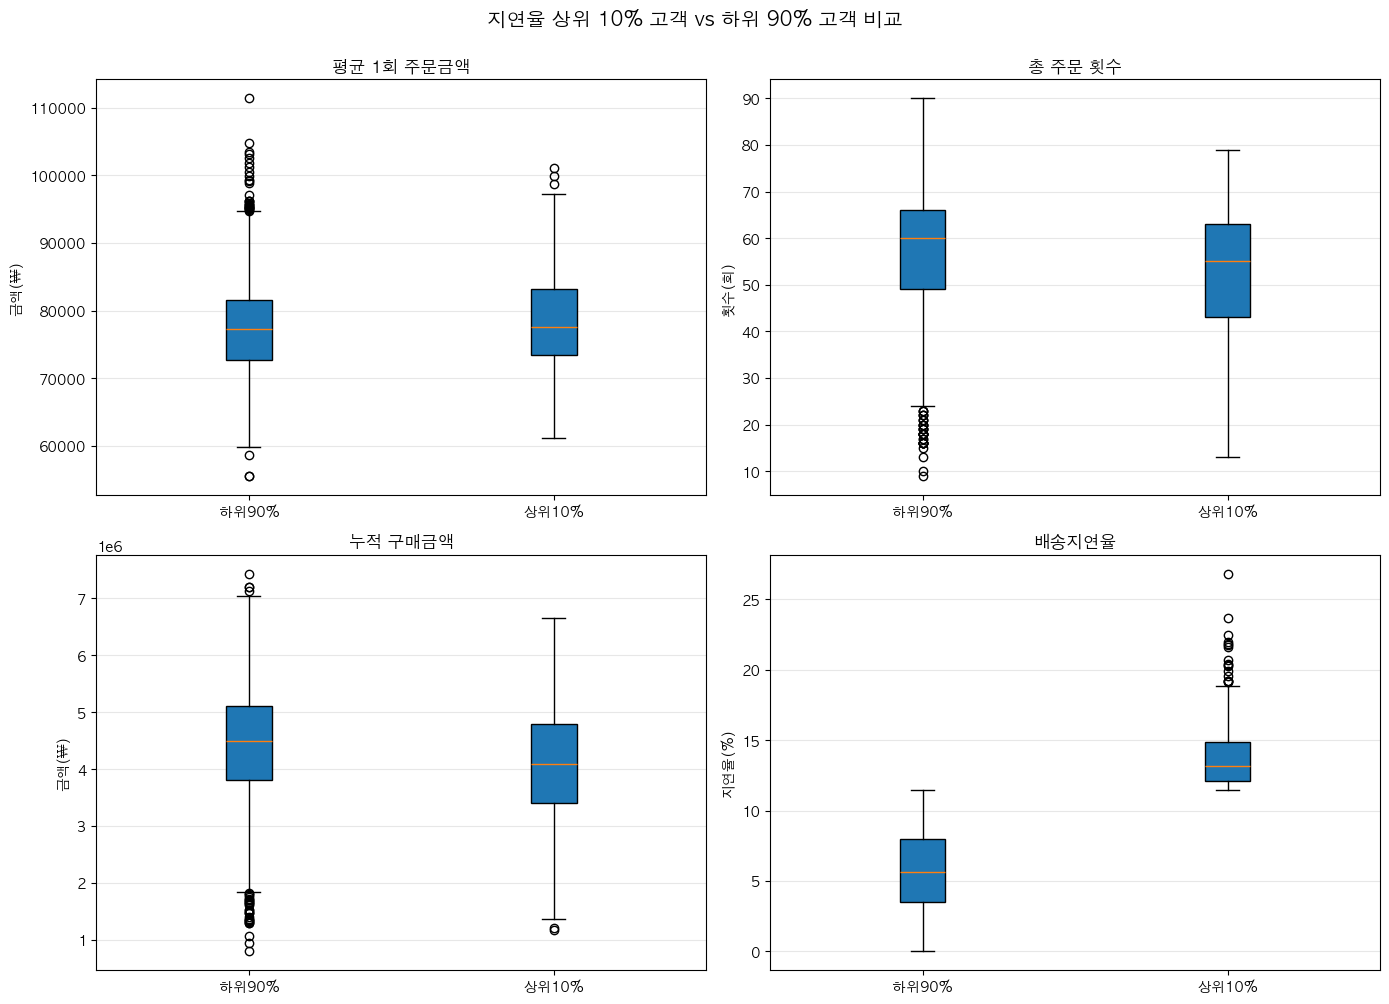


[핵심 인사이트]
  1. 상위 10% 고객은 하위 90%보다 -8.6% 더 많이 주문
  2. 상위 10% 고객은 하위 90%보다 -7.8% 더 많이 구매
  3. 지연 경험이 많은 고객 = 평균적 구매자의 특성
  4. → 배송 품질 개선은 균형잡힌 위험도 존재


In [37]:
# 지연율 상위 10% 고객 프로필 분석
print("\n" + "=" * 60)
print("지연율 상위 10% 고객 vs 나머지 고객 비교 분석")
print("=" * 60)

# 상위 10% 임계값 계산
threshold_90 = customer_final['delay_rate'].quantile(0.90)
print(f"\n✓ 지연율 상위 10% 임계값: {threshold_90:.2f}%")

# 고객 분류
high_delay = customer_final[customer_final['delay_rate'] >= threshold_90]
low_delay = customer_final[customer_final['delay_rate'] < threshold_90]

print(f"✓ 상위 10% 고객 수: {len(high_delay)} 명")
print(f"✓ 하위 90% 고객 수: {len(low_delay)} 명")

# 비교 지표 정의
compare_metrics = ['avg_order_amount', 'avg_order_item_count', 'total_order_count', 'total_spend']

# 상세 비교 테이블
comparison_df = pd.DataFrame({
    '지표': compare_metrics,
    '상위10% 평균': [high_delay[col].mean() for col in compare_metrics],
    '상위10% 중앙값': [high_delay[col].median() for col in compare_metrics],
    '하위90% 평균': [low_delay[col].mean() for col in compare_metrics],
    '하위90% 중앙값': [low_delay[col].median() for col in compare_metrics],
})

# 평균 차이 및 백분비 계산
comparison_df['평균 차이'] = comparison_df['상위10% 평균'] - comparison_df['하위90% 평균']
comparison_df['차이율(%)'] = ((comparison_df['상위10% 평균'] - comparison_df['하위90% 평균']) / 
                              comparison_df['하위90% 평균'] * 100).round(2)

print(f"\n[상위 10% vs 하위 90% 비교]")
print(comparison_df.to_string(index=False))

# 지연율 통계
print(f"\n[지연율 비교]")
print(f"  상위 10% 지연율: 평균={high_delay['delay_rate'].mean():.2f}%, "
      f"범위={high_delay['delay_rate'].min():.2f}% ~ {high_delay['delay_rate'].max():.2f}%")
print(f"  하위 90% 지연율: 평균={low_delay['delay_rate'].mean():.2f}%, "
      f"범위={low_delay['delay_rate'].min():.2f}% ~ {low_delay['delay_rate'].max():.2f}%")

# 시각화 (3x2 그리드)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('지연율 상위 10% 고객 vs 하위 90% 고객 비교', fontsize=14, fontweight='bold', y=1.00)

# 1. avg_order_amount
axes[0, 0].boxplot([low_delay['avg_order_amount'], high_delay['avg_order_amount']], 
                    labels=['하위90%', '상위10%'], patch_artist=True)
axes[0, 0].set_title('평균 1회 주문금액')
axes[0, 0].set_ylabel('금액(₩)')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. total_order_count
axes[0, 1].boxplot([low_delay['total_order_count'], high_delay['total_order_count']], 
                    labels=['하위90%', '상위10%'], patch_artist=True)
axes[0, 1].set_title('총 주문 횟수')
axes[0, 1].set_ylabel('횟수(회)')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. total_spend
axes[1, 0].boxplot([low_delay['total_spend'], high_delay['total_spend']], 
                    labels=['하위90%', '상위10%'], patch_artist=True)
axes[1, 0].set_title('누적 구매금액')
axes[1, 0].set_ylabel('금액(₩)')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. delay_rate
axes[1, 1].boxplot([low_delay['delay_rate'], high_delay['delay_rate']], 
                    labels=['하위90%', '상위10%'], patch_artist=True)
axes[1, 1].set_title('배송지연율')
axes[1, 1].set_ylabel('지연율(%)')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 핵심 인사이트
print(f"\n[핵심 인사이트]")
high_order_pct = ((high_delay['total_order_count'].mean() - low_delay['total_order_count'].mean()) / 
                  low_delay['total_order_count'].mean() * 100)
high_spend_pct = ((high_delay['total_spend'].mean() - low_delay['total_spend'].mean()) / 
                  low_delay['total_spend'].mean() * 100)

print(f"  1. 상위 10% 고객은 하위 90%보다 {high_order_pct:+.1f}% 더 많이 주문")
print(f"  2. 상위 10% 고객은 하위 90%보다 {high_spend_pct:+.1f}% 더 많이 구매")
print(f"  3. 지연 경험이 많은 고객 = {('빈번한 구매자' if high_order_pct > 5 else '평균적 구매자')}의 특성")
print(f"  4. → 배송 품질 개선은 {'고객 충성도 저하' if high_spend_pct > 5 else '균형잡힌'} 위험도 존재")

# 추가 분석: 주문 시간대별 배송지연률

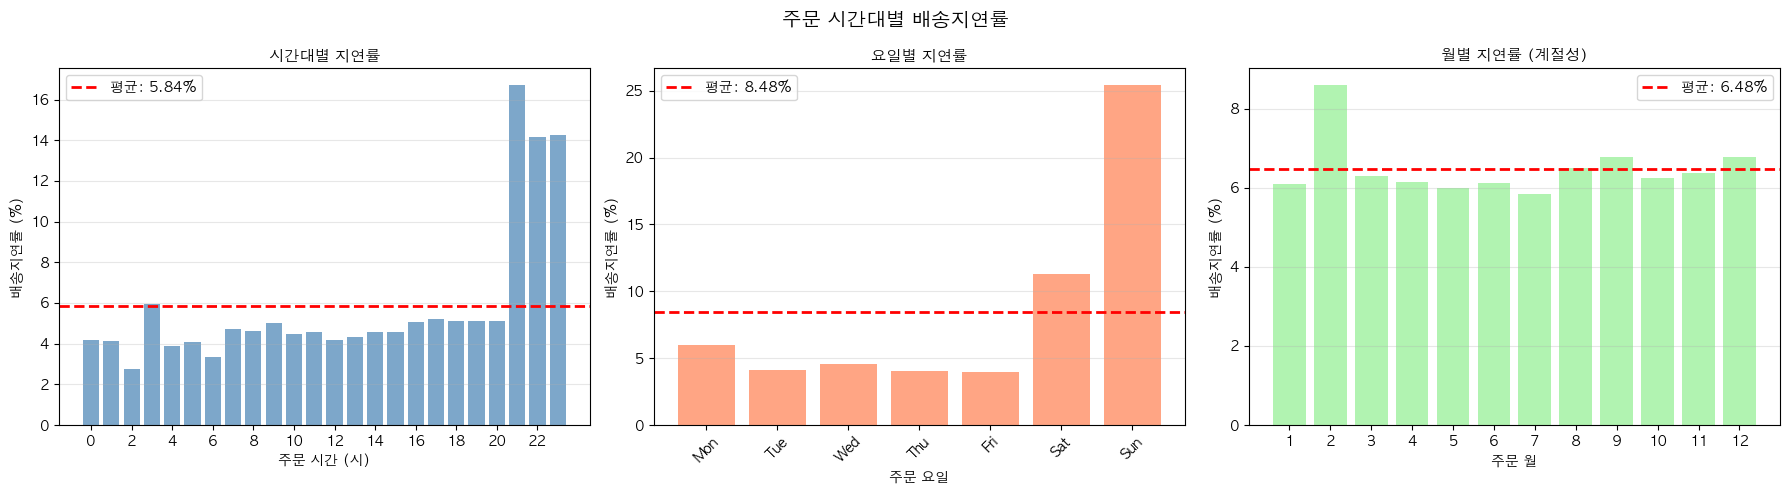


=== 주문 시간대별 배송지연률 요약 ===

시간대별 지연률:
OrderHour
0      4.19
1      4.14
2      2.73
3      5.94
4      3.88
5      4.06
6      3.35
7      4.74
8      4.64
9      5.02
10     4.47
11     4.57
12     4.20
13     4.32
14     4.57
15     4.55
16     5.08
17     5.19
18     5.12
19     5.10
20     5.13
21    16.70
22    14.17
23    14.27
Name: IsLate, dtype: float64

요일별 지연률:
OrderWeekday
Monday        5.98
Tuesday       4.12
Wednesday     4.56
Thursday      4.06
Friday        3.94
Saturday     11.29
Sunday       25.40
Name: IsLate, dtype: float64

월별 지연률:
OrderMonth
1     6.10
2     8.59
3     6.31
4     6.16
5     6.00
6     6.13
7     5.84
8     6.50
9     6.77
10    6.25
11    6.38
12    6.79
Name: IsLate, dtype: float64


In [38]:
# 주문 시간대별, 요일별, 월별 배송지연률 분석
matplotlib.rc("font", family="AppleGothic")
matplotlib.rc("axes", unicode_minus=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('주문 시간대별 배송지연률', fontsize=14, fontweight='bold')

# 1. 시간대별 (OrderHour: 0~23시)
hour_delay = df.groupby('OrderHour')['IsLate'].mean() * 100
hour_delay = hour_delay.sort_index()
axes[0].bar(hour_delay.index, hour_delay.values, color='steelblue', alpha=0.7)
axes[0].axhline(hour_delay.mean(), color='red', linestyle='--', linewidth=2, label=f'평균: {hour_delay.mean():.2f}%')
axes[0].set_title('시간대별 지연률', fontsize=11)
axes[0].set_xlabel('주문 시간 (시)', fontsize=10)
axes[0].set_ylabel('배송지연률 (%)', fontsize=10)
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

# 2. 요일별 (OrderWeekday: 월~일 정렬)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_delay = df.groupby('OrderWeekday')['IsLate'].mean() * 100
weekday_delay = weekday_delay.reindex([w for w in weekday_order if w in weekday_delay.index])
axes[1].bar(range(len(weekday_delay)), weekday_delay.values, color='coral', alpha=0.7)
axes[1].axhline(weekday_delay.mean(), color='red', linestyle='--', linewidth=2, label=f'평균: {weekday_delay.mean():.2f}%')
axes[1].set_title('요일별 지연률', fontsize=11)
axes[1].set_xlabel('주문 요일', fontsize=10)
axes[1].set_ylabel('배송지연률 (%)', fontsize=10)
axes[1].set_xticks(range(len(weekday_delay)))
axes[1].set_xticklabels([w[:3] for w in weekday_delay.index], rotation=45)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend()

# 3. 월별 (OrderMonth: 1~12월)
month_delay = df.groupby('OrderMonth')['IsLate'].mean() * 100
month_delay = month_delay.sort_index()
axes[2].bar(month_delay.index, month_delay.values, color='lightgreen', alpha=0.7)
axes[2].axhline(month_delay.mean(), color='red', linestyle='--', linewidth=2, label=f'평균: {month_delay.mean():.2f}%')
axes[2].set_title('월별 지연률 (계절성)', fontsize=11)
axes[2].set_xlabel('주문 월', fontsize=10)
axes[2].set_ylabel('배송지연률 (%)', fontsize=10)
axes[2].set_xticks(range(1, 13))
axes[2].grid(axis='y', alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== 주문 시간대별 배송지연률 요약 ===")
print(f"\n시간대별 지연률:")
print(hour_delay.round(2))
print(f"\n요일별 지연률:")
print(weekday_delay.round(2))
print(f"\n월별 지연률:")
print(month_delay.round(2))

# 추가 분석: 상품 카테고리별 배송지연률

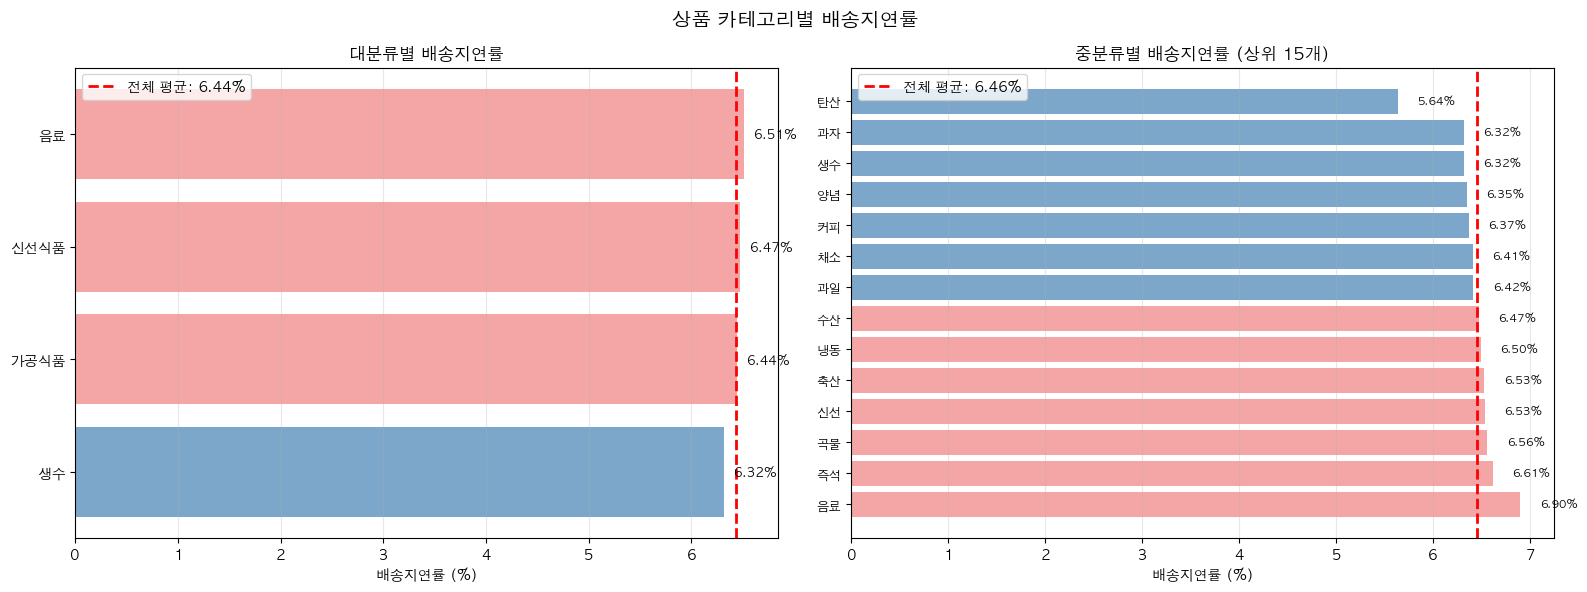


=== 상품 카테고리별 배송지연률 요약 ===

대분류별 지연률:
ItemLargeName
음료      6.51
신선식품    6.47
가공식품    6.44
생수      6.32
Name: IsLate, dtype: float64

중분류별 지연률 (상위 10개):
ItemMiddleName
음료    6.90
즉석    6.61
곡물    6.56
신선    6.53
축산    6.53
냉동    6.50
수산    6.47
과일    6.42
채소    6.41
커피    6.37
Name: IsLate, dtype: float64

중분류별 지연률 (하위 10개):
ItemMiddleName
탄산    5.64
과자    6.32
생수    6.32
양념    6.35
커피    6.37
채소    6.41
과일    6.42
수산    6.47
냉동    6.50
축산    6.53
Name: IsLate, dtype: float64


In [39]:
# 상품 카테고리별 배송지연률 분석
matplotlib.rc("font", family="AppleGothic")
matplotlib.rc("axes", unicode_minus=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('상품 카테고리별 배송지연률', fontsize=14, fontweight='bold')

# 1. 대분류(ItemLargeName)별 지연률 - 내림차순 정렬
large_delay = df.groupby('ItemLargeName')['IsLate'].mean() * 100
large_delay = large_delay.sort_values(ascending=True)
colors_large = ['lightcoral' if x > large_delay.mean() else 'steelblue' for x in large_delay.values]
axes[0].barh(range(len(large_delay)), large_delay.values, color=colors_large, alpha=0.7)
axes[0].axvline(large_delay.mean(), color='red', linestyle='--', linewidth=2, label=f'전체 평균: {large_delay.mean():.2f}%')
axes[0].set_title('대분류별 배송지연률', fontsize=12, fontweight='bold')
axes[0].set_xlabel('배송지연률 (%)', fontsize=10)
axes[0].set_yticks(range(len(large_delay)))
axes[0].set_yticklabels(large_delay.index, fontsize=10)
axes[0].grid(axis='x', alpha=0.3)
axes[0].legend()

# 대분류별 지연률 수치 표시
for i, v in enumerate(large_delay.values):
    axes[0].text(v + 0.1, i, f'{v:.2f}%', va='center', fontsize=9)

# 2. 중분류(ItemMiddleName)별 지연률 - 상위 15개, 내림차순 정렬
middle_delay = df.groupby('ItemMiddleName')['IsLate'].mean() * 100
middle_delay = middle_delay.sort_values(ascending=False).head(15)
colors_middle = ['lightcoral' if x > df['IsLate'].mean() * 100 else 'steelblue' for x in middle_delay.values]
axes[1].barh(range(len(middle_delay)), middle_delay.values, color=colors_middle, alpha=0.7)
axes[1].axvline(df['IsLate'].mean() * 100, color='red', linestyle='--', linewidth=2, label=f'전체 평균: {df["IsLate"].mean() * 100:.2f}%')
axes[1].set_title('중분류별 배송지연률 (상위 15개)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('배송지연률 (%)', fontsize=10)
axes[1].set_yticks(range(len(middle_delay)))
axes[1].set_yticklabels(middle_delay.index, fontsize=9)
axes[1].grid(axis='x', alpha=0.3)
axes[1].legend()

# 중분류별 지연률 수치 표시
for i, v in enumerate(middle_delay.values):
    axes[1].text(v + 0.2, i, f'{v:.2f}%', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# 통계 요약
print("\n=== 상품 카테고리별 배송지연률 요약 ===")
print(f"\n대분류별 지연률:")
print(large_delay.sort_values(ascending=False).round(2))
print(f"\n중분류별 지연률 (상위 10개):")
print(middle_delay.head(10).round(2))
print(f"\n중분류별 지연률 (하위 10개):")
print(df.groupby('ItemMiddleName')['IsLate'].mean().sort_values(ascending=True).head(10).mul(100).round(2))

# 파생변수 신규

In [40]:
import pandas as pd
import numpy as np

print("\n" + "=" * 60)
print("새 파생변수 생성 - 시간 패턴, 카테고리, 인구통계")
print("=" * 60)

# 날짜 변환
df['OrderDT_dt'] = pd.to_datetime(df['OrderDT'])
df['DeliveryDT_dt'] = pd.to_datetime(df['DeliveryDT'])
df['delivery_hours'] = (df['DeliveryDT_dt'] - df['OrderDT_dt']).dt.total_seconds() / 3600
df['is_weekend'] = df['OrderWeekday'].isin(['Saturday', 'Sunday']).astype(int)
df['is_night'] = ((df['OrderHour'] >= 22) | (df['OrderHour'] <= 5)).astype(int)

# 그룹 1: 시간 패턴 변수
time_vars = df.groupby('idUser').agg(
    weekend_order_ratio=('is_weekend', 'mean'),
    night_order_ratio=('is_night', 'mean'),
    avg_delivery_hours=('delivery_hours', 'mean'),
).reset_index()

# 그룹 2: 카테고리 변수
category_vars = df.groupby('idUser').agg(
    category_diversity=('ItemLargeName', 'nunique'),
).reset_index()

# 신선식품 비율 (ItemLargeName 기준)
fresh_keywords = ['수산', '축산', '청과', '신선', '쌀', '농산']
df['is_fresh'] = df['ItemLargeName'].str.contains('|'.join(fresh_keywords), na=False).astype(int)
fresh_vars = df.groupby('idUser').agg(fresh_food_ratio=('is_fresh', 'mean')).reset_index()

# 그룹 3: 인구통계 변수
demo_vars = df.groupby('idUser').agg(
    gender=('Gender', 'first'),
    age=('Age', 'first'),
    family_count=('FamilyCount', 'first'),
    member_yn=('MemberYN', 'first'),
).reset_index()

# customer_final에 합치기
customer_extended = customer_final.copy()
for new_df in [time_vars, category_vars, fresh_vars, demo_vars]:
    customer_extended = customer_extended.merge(new_df, on='idUser', how='left')

print(f"\n확장된 customer_extended 크기: {customer_extended.shape}")
print(f"컬럼 수: {len(customer_extended.columns)}")
print(f"\n새로 추가된 컬럼:")
for col in customer_extended.columns[13:]:  # customer_final 이후의 컬럼
    print(f"  - {col}")

print(f"\n[변수별 기초통계]")
print(customer_extended[['weekend_order_ratio', 'night_order_ratio', 'avg_delivery_hours',
                         'category_diversity', 'fresh_food_ratio', 'age', 'family_count']].describe().round(3))


새 파생변수 생성 - 시간 패턴, 카테고리, 인구통계

확장된 customer_extended 크기: (3000, 22)
컬럼 수: 22

새로 추가된 컬럼:
  - weekend_order_ratio
  - night_order_ratio
  - avg_delivery_hours
  - category_diversity
  - fresh_food_ratio
  - gender
  - age
  - family_count
  - member_yn

[변수별 기초통계]
       weekend_order_ratio  night_order_ratio  avg_delivery_hours  \
count             3000.000           3000.000            3000.000   
mean                 0.184              0.110              17.637   
std                  0.088              0.046               1.364   
min                  0.000              0.000              13.603   
25%                  0.122              0.077              16.702   
50%                  0.178              0.106              17.554   
75%                  0.237              0.138              18.478   
max                  0.649              0.341              24.750   

       category_diversity  fresh_food_ratio       age  family_count  
count            3000.000          3000.000


새 파생변수 × 배송지연율(order_delay_rate) 상관관계 분석

[수치형 변수 상관계수]
                 지표  상관계수(r)  p-value       유의성
 avg_delivery_hours   0.4232 0.000000     ✓ 유의함
weekend_order_ratio   0.2492 0.000000     ✓ 유의함
  night_order_ratio   0.0523 0.004190     ✓ 유의함
   fresh_food_ratio   0.0273 0.134903 ✗ 유의하지 않음
       family_count  -0.0146 0.424889 ✗ 유의하지 않음
 category_diversity   0.0089 0.627620 ✗ 유의하지 않음
                age   0.0062 0.735213 ✗ 유의하지 않음

범주형 변수별 배송지연율 비교

[gender별 order_delay_rate 기초통계]
        count  mean   std  min    max
gender                               
남성       1190  6.38  3.54  0.0  20.00
여성       1810  6.53  3.69  0.0  25.49

[member_yn별 order_delay_rate 기초통계]
           count  mean   std  min    max
member_yn                               
N            845  6.36  3.58  0.0  20.00
Y           2155  6.52  3.65  0.0  25.49

[유의한 상관 발견 여부]
✓ 3개 변수에서 유의한 상관 발견:
  - avg_delivery_hours: r=0.4232, p=0.000000
  - weekend_order_ratio: r=0.2492, p=0.000000
  - night_order_ratio: r=0.0

/var/folders/cg/m63vxzr11690z4xpkx8d511r0000gn/T/ipykernel_7090/2414099888.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([old_results, result_df2['상관계수(r)'].tolist()],


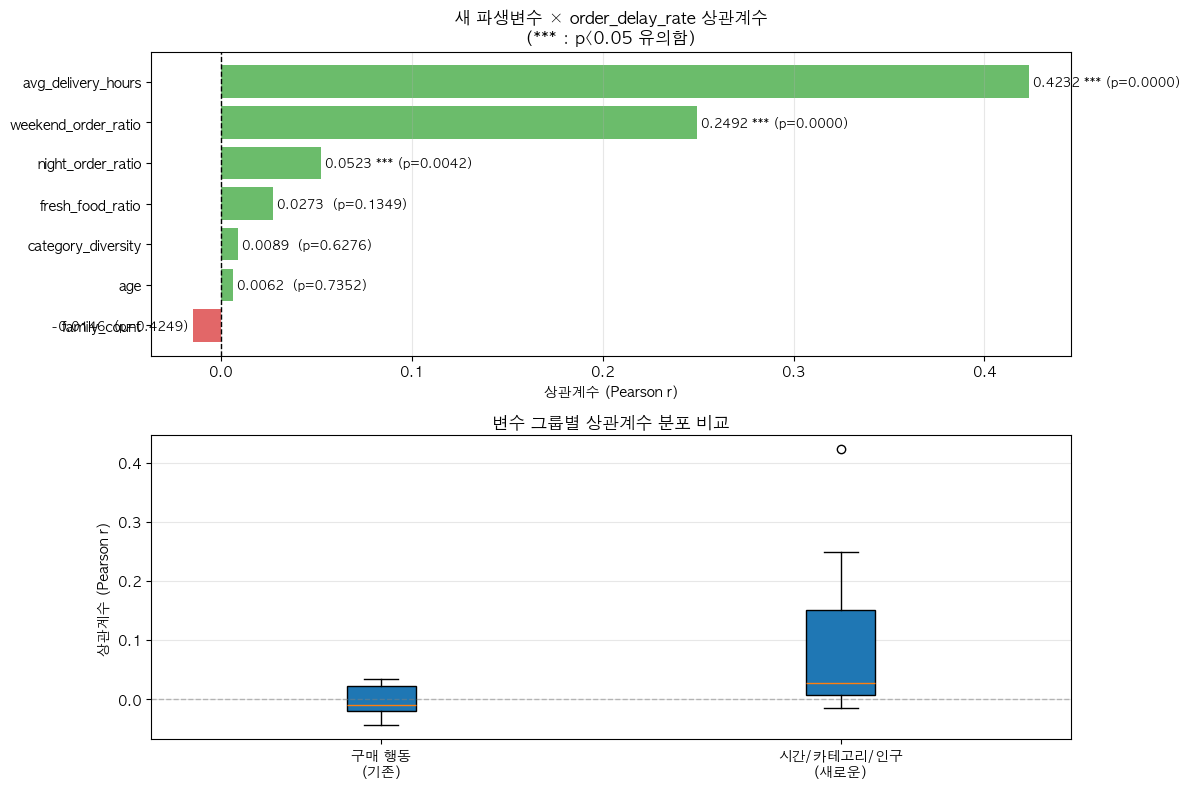

In [41]:
from scipy import stats

print("\n" + "=" * 60)
print("새 파생변수 × 배송지연율(order_delay_rate) 상관관계 분석")
print("=" * 60)

# 수치형 변수들의 상관계수 및 p-value
new_numeric_cols = ['weekend_order_ratio', 'night_order_ratio', 'avg_delivery_hours',
                    'category_diversity', 'fresh_food_ratio', 'age', 'family_count']

results = []
for col in new_numeric_cols:
    mask = customer_extended[[col, 'order_delay_rate']].dropna()
    r, p = stats.pearsonr(mask[col], mask['order_delay_rate'])
    results.append({
        '지표': col, 
        '상관계수(r)': round(r, 4), 
        'p-value': round(p, 6),
        '유의성': '✓ 유의함' if p < 0.05 else '✗ 유의하지 않음'
    })

result_df2 = pd.DataFrame(results).sort_values('상관계수(r)', key=abs, ascending=False)
print("\n[수치형 변수 상관계수]")
print(result_df2.to_string(index=False))

# 범주형 변수 분석
print("\n" + "=" * 60)
print("범주형 변수별 배송지연율 비교")
print("=" * 60)

for cat_col in ['gender', 'member_yn']:
    print(f"\n[{cat_col}별 order_delay_rate 기초통계]")
    group_stats = customer_extended.groupby(cat_col)['order_delay_rate'].agg([
        'count', 'mean', 'std', 'min', 'max'
    ]).round(2)
    print(group_stats)

# 성별, 회원여부 카이제곱 검정
print("\n[유의한 상관 발견 여부]")
found_sig = result_df2[result_df2['p-value'] < 0.05]
if len(found_sig) > 0:
    print(f"✓ {len(found_sig)}개 변수에서 유의한 상관 발견:")
    for _, row in found_sig.iterrows():
        print(f"  - {row['지표']}: r={row['상관계수(r)']:.4f}, p={row['p-value']:.6f}")
else:
    print(f"✗ 유의한 상관을 보이는 변수 없음 (p >= 0.05)")
    print(f"  → 구매 금액/빈도뿐 아니라 시간, 카테고리, 인구통계도 배송지연율과 무관")

# 시각화
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# 1. 수치형 변수 상관계수 바그래프
ax1 = axes[0]
result_sorted = result_df2.sort_values('상관계수(r)')
colors = ['#d62728' if x < 0 else '#2ca02c' for x in result_sorted['상관계수(r)']]
bars = ax1.barh(result_sorted['지표'], result_sorted['상관계수(r)'], color=colors, alpha=0.7)

for i, row in enumerate(result_sorted.itertuples()):
    sig_marker = '***' if row._3 < 0.05 else ''
    label = f'{row._2:.4f} {sig_marker} (p={row._3:.4f})'
    x_pos = row._2 + 0.002 if row._2 >= 0 else row._2 - 0.002
    ha = 'left' if row._2 >= 0 else 'right'
    ax1.text(x_pos, i, label, va='center', ha=ha, fontsize=9)

ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax1.set_title('새 파생변수 × order_delay_rate 상관계수\n(*** : p<0.05 유의함)', fontsize=12, fontweight='bold')
ax1.set_xlabel('상관계수 (Pearson r)')
ax1.grid(axis='x', alpha=0.3)

# 2. 기존 구매 변수 vs 새 파생변수 비교
ax2 = axes[1]
old_vars = ['avg_order_amount', 'avg_order_item_count', 'total_order_count',
            'total_spend', 'max_order_amount', 'min_order_amount',
            'order_amount_std', 'order_amount_range']

old_results = []
for col in old_vars:
    mask = customer_extended[[col, 'order_delay_rate']].dropna()
    r, _ = stats.pearsonr(mask[col], mask['order_delay_rate'])
    old_results.append(r)

comparison_data = {
    '그룹': ['구매 행동\n(기존)'] * len(old_results) + ['시간/카테고리/인구통계\n(새로운)'] * len(result_df2),
    '상관계수': old_results + result_df2['상관계수(r)'].tolist(),
}

# 박스플롯으로 분포 비교
ax2.boxplot([old_results, result_df2['상관계수(r)'].tolist()],
            labels=['구매 행동\n(기존)', '시간/카테고리/인구\n(새로운)'],
            patch_artist=True)
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_ylabel('상관계수 (Pearson r)')
ax2.set_title('변수 그룹별 상관계수 분포 비교', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
customer_extended.head()

,idUser,avg_order_amount,avg_order_item_count,total_order_count,total_spend,max_order_amount,min_order_amount,order_amount_std,order_amount_range,delay_count,...,order_delay_rate,weekend_order_ratio,night_order_ratio,avg_delivery_hours,category_diversity,fresh_food_ratio,gender,age,family_count,member_yn
0,U10001,78478.115942,5.028986,69,5414990,152430,13420,34811.675960,139010,60,...,14.49,0.129683,0.077810,18.805886,4,0.507205,여성,26,2,Y
1,U10002,74466.981132,5.075472,53,3946750,170840,6170,36683.304449,164670,37,...,13.21,0.267658,0.223048,20.605075,3,0.486989,남성,61,2,Y
2,U10003,89794.339623,5.452830,53,4759100,175320,15850,38943.382894,159470,0,...,0.00,0.114187,0.027682,15.948257,4,0.477509,여성,34,2,Y
3,U10004,75709.696970,4.878788,33,2498420,155150,8830,30789.800410,146320,7,...,6.06,0.037267,0.130435,16.665267,3,0.503106,남성,26,1,N
4,U10005,71330.384615,4.756410,78,5563770,167590,2430,29031.230897,165160,13,...,3.85,0.288410,0.137466,16.951698,4,0.533693,여성,33,3,Y


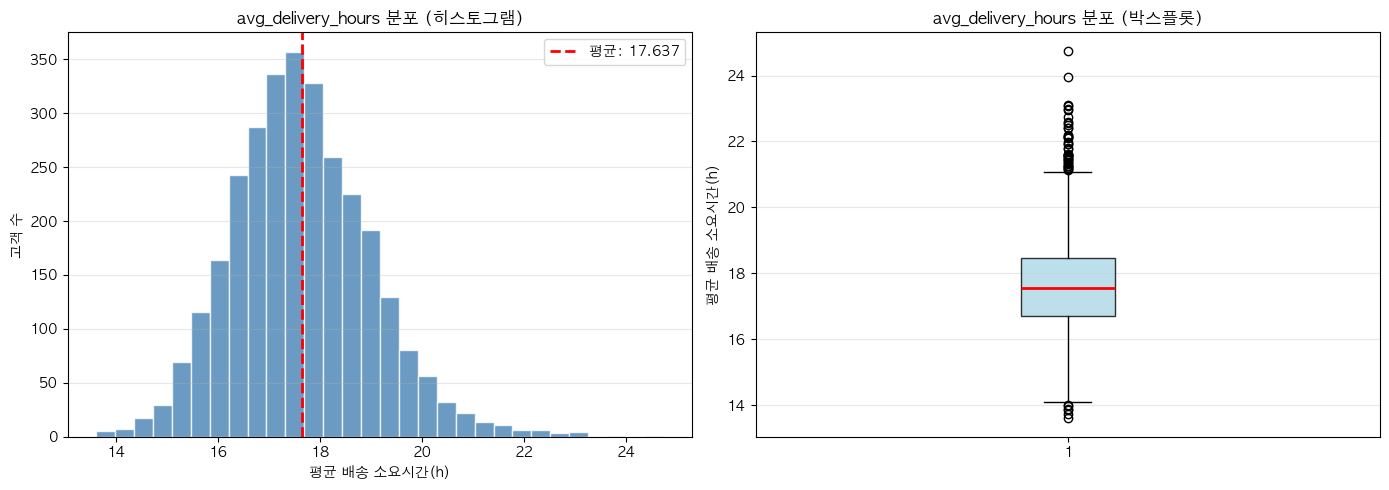

avg_delivery_hours 통계
count    3000.000000
mean       17.637173
std         1.364000
min        13.602786
25%        16.701569
50%        17.554495
75%        18.478400
max        24.749901
Name: avg_delivery_hours, dtype: float64

왜도 (Skewness): 0.480
첨도 (Kurtosis): 0.884


In [43]:
import matplotlib.pyplot as plt
import numpy as np

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# avg_delivery_days 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램 (분포)
axes[0].hist(customer_extended['avg_delivery_hours'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
mean_val = customer_extended['avg_delivery_hours'].mean()
axes[0].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f"평균: {mean_val:.3f}")
axes[0].set_title('avg_delivery_hours 분포 (히스토그램)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('평균 배송 소요시간(h)')
axes[0].set_ylabel('고객 수')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# 박스플롯 (이상치 확인)
box_plot = axes[1].boxplot(customer_extended['avg_delivery_hours'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.8),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('avg_delivery_hours 분포 (박스플롯)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('평균 배송 소요시간(h)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('avg_delivery_hours_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 통계 정보
print("=" * 50)
print("avg_delivery_hours 통계")
print("=" * 50)
print(customer_extended['avg_delivery_hours'].describe())
print(f"\n왜도 (Skewness): {customer_extended['avg_delivery_hours'].skew():.3f}")
print(f"첨도 (Kurtosis): {customer_extended['avg_delivery_hours'].kurtosis():.3f}")